In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import warnings
warnings.filterwarnings('ignore')

# Statistical and ML imports
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

# Load the Anthropic Persuasion Dataset
print("Loading Anthropic Persuasion Dataset...")
ds = load_dataset("Anthropic/persuasion")
print(f"Dataset loaded successfully!")
print(f"Split: {ds.keys()}")
print(f"Dataset size: {len(ds['train'])} records")

Loading Anthropic Persuasion Dataset...


README.md: 0.00B [00:00, ?B/s]

persuasion_data.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/3939 [00:00<?, ? examples/s]

Dataset loaded successfully!
Split: dict_keys(['train'])
Dataset size: 3939 records


In [2]:
# Dataset Structure
# Convert to DataFrame for easier manipulation
df = pd.DataFrame(ds['train'])
print(f"\nDataFrame shape: {df.shape}")
print(f"\nColumn names and types:")
print(df.dtypes)
print(f"\nFirst few rows:")
df.head()


DataFrame shape: (3939, 8)

Column names and types:
worker_id                object
claim                    object
argument                 object
source                   object
prompt_type              object
rating_initial           object
rating_final             object
persuasiveness_metric     int64
dtype: object

First few rows:


,worker_id,claim,argument,source,prompt_type,rating_initial,rating_final,persuasiveness_metric
0,PQVTZECGNK3K,Governments and technology companies must do m...,It's time for governments and tech companies t...,Claude 2,Expert Writer Rhetorics,7 - Strongly support,7 - Strongly support,0
1,3KTT9HNPV9WX,Governments and technology companies must do m...,"In today's hyper-connected world, our personal...",Claude 3 Haiku,Expert Writer Rhetorics,7 - Strongly support,7 - Strongly support,0
2,M76GMRF46C69,Cultured/lab-grown meats should be allowed to ...,The future of food must include cultured/lab-g...,Claude 2,Compelling Case,3 - Somewhat oppose,5 - Somewhat support,2
3,3W4KKCTPTP7R,Social media companies should be required to l...,Social media companies should be required to l...,Claude 2,Compelling Case,3 - Somewhat oppose,6 - Support,3
4,QQDKMRY3HRXJ,Employers should be allowed to monitor employe...,Allowing employers to monitor employees throug...,Claude 3 Opus,Logical Reasoning,5 - Somewhat support,5 - Somewhat support,0


In [3]:
# Statistical Summary
print("\nNumerical Columns Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nCategorical Variables Unique Values:")
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")
    if df[col].nunique() <= 10:
        print(f"  Values: {df[col].unique()}")


Numerical Columns Summary:
       persuasiveness_metric
count            3939.000000
mean                0.417111
std                 0.886626
min                -2.000000
25%                 0.000000
50%                 0.000000
75%                 1.000000
max                 5.000000

Missing Values:
worker_id                  0
claim                      0
argument                   0
source                     0
prompt_type              522
rating_initial             0
rating_final               0
persuasiveness_metric      0
dtype: int64

Categorical Variables Unique Values:
worker_id: 3832 unique values
claim: 75 unique values
argument: 1313 unique values
source: 7 unique values
  Values: ['Claude 2' 'Claude 3 Haiku' 'Claude 3 Opus' 'Claude Instant 1.2'
 'Claude 1.3' 'Human' 'Control']
prompt_type: 5 unique values
  Values: ['Expert Writer Rhetorics' 'Compelling Case' 'Logical Reasoning'
 'Deceptive' None 'Control Prompt']
rating_initial: 7 unique values
  Values: ['7 - Strongl

In [4]:
# DATA PRE-PROCESSING
import re
import string

def clean_text(text):
    """
    Apply basic text cleaning: lowercase, remove punctuation, remove extra whitespace
    """
    if not isinstance(text, str):
        return ""
    # Lowercase
    text = text.lower()
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# 1. Rating Conversion (Text to Numeric)
rating_map = {
    '1 - Strongly oppose': 1,
    '2 - Oppose': 2,
    '3 - Somewhat oppose': 3,
    '4 - Neither oppose nor support': 4,
    '5 - Somewhat support': 5,
    '6 - Support': 6,
    '7 - Strongly support': 7
}

print("Converting categorical ratings to numeric scale (1-7)...")
df['rating_initial_num'] = df['rating_initial'].map(rating_map)
df['rating_final_num'] = df['rating_final'].map(rating_map)

# Replace original columns with numeric ones for compatibility with existing code
df['rating_initial'] = df['rating_initial_num']
df['rating_final'] = df['rating_final_num']

# 2. Text Cleaning
print("Cleaning argument text for feature extraction...")
df['argument_cleaned'] = df['argument'].apply(clean_text)

# 3. Handle Missing Values
print("Handling missing values...")
df['prompt_type'] = df['prompt_type'].fillna('Unknown')
# Drop rows where ratings couldn't be converted
df = df.dropna(subset=['rating_initial', 'rating_final']).copy()

# 4. Source Type Classification
print("Classifying sources (AI vs Human)...")
df['source_type'] = df['source'].apply(lambda x: 'AI' if any(ai in x.lower() for ai in ['claude', 'gpt', 'ai']) else 'Human')

print(f"\nPre-processing complete. Processed {len(df)} records.")
df[['source', 'source_type', 'rating_initial', 'rating_final']].head()

Converting categorical ratings to numeric scale (1-7)...
Cleaning argument text for feature extraction...
Handling missing values...
Classifying sources (AI vs Human)...

Pre-processing complete. Processed 3939 records.


,source,source_type,rating_initial,rating_final
0,Claude 2,AI,7,7
1,Claude 3 Haiku,AI,7,7
2,Claude 2,AI,3,5
3,Claude 2,AI,3,6
4,Claude 3 Opus,AI,5,5


In [5]:
# OBJECTIVE 1: Measure Persuasion Changes
# Calculate persuasion shift: rating_final - rating_initial
df['persuasion_shift'] = df['rating_final'] - df['rating_initial']
df['persuasion_shift_abs'] = df['persuasion_shift'].abs()  # Absolute shift magnitude

print("\nPersuasion Shift Statistics:")
print(df['persuasion_shift'].describe())

print("\nPersuasion Shift Distribution:")
print(df['persuasion_shift'].value_counts().sort_index())

# Categorize persuasion outcomes
df['persuasion_direction'] = pd.cut(df['persuasion_shift'],
                                     bins=[-np.inf, -1, 1, np.inf],
                                     labels=['More Opposed', 'Minimal Change', 'More Persuaded'])

print("\nPersuasion Direction Distribution:")
print(df['persuasion_direction'].value_counts())
print(f"\nPercentage:")
print((df['persuasion_direction'].value_counts() / len(df) * 100).round(2))


Persuasion Shift Statistics:
count    3939.000000
mean        0.415080
std         0.887579
min        -2.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         5.000000
Name: persuasion_shift, dtype: float64

Persuasion Shift Distribution:
persuasion_shift
-2       4
-1     240
 0    2422
 1     834
 2     305
 3     100
 4      31
 5       3
Name: count, dtype: int64

Persuasion Direction Distribution:
persuasion_direction
Minimal Change    3256
More Persuaded     439
More Opposed       244
Name: count, dtype: int64

Percentage:
persuasion_direction
Minimal Change    82.66
More Persuaded    11.14
More Opposed       6.19
Name: count, dtype: float64


In [6]:
# Analyze Persuasion Changes by Source and Prompt Type
print("\n\nPersuasion Shift by Source:")
persuasion_by_source = df.groupby('source').agg({
    'persuasion_shift': ['mean', 'median', 'std', 'count'],
    'rating_initial': 'mean',
    'rating_final': 'mean'
}).round(3)
print(persuasion_by_source)

print("\n\nPersuasion Shift by Prompt Type:")
persuasion_by_prompt = df.groupby('prompt_type').agg({
    'persuasion_shift': ['mean', 'median', 'std', 'count'],
    'rating_initial': 'mean',
    'rating_final': 'mean'
}).round(3)
print(persuasion_by_prompt)

print("\n\nPersuasion Shift by Source and Prompt Type:")
persuasion_by_both = df.groupby(['source', 'prompt_type']).agg({
    'persuasion_shift': ['mean', 'median', 'std', 'count']
}).round(3)
persuasion_by_both



Persuasion Shift by Source:
                   persuasion_shift                     rating_initial  \
                               mean median    std count           mean   
source                                                                   
Claude 1.3                    0.344    0.0  0.877   672          4.213   
Claude 2                      0.424    0.0  0.889   672          4.155   
Claude 3 Haiku                0.435    0.0  0.868   672          4.210   
Claude 3 Opus                 0.482    0.0  0.953   672          4.186   
Claude Instant 1.2            0.335    0.0  0.863   672          4.039   
Control                      -0.070    0.0  0.417    57          6.789   
Human                         0.540    0.0  0.876   522          4.136   

                   rating_final  
                           mean  
source                           
Claude 1.3                4.557  
Claude 2                  4.579  
Claude 3 Haiku            4.644  
Claude 3 Opus            

persuasion_shift                \
                                                       mean median    std   
source             prompt_type                                              
Claude 1.3         Compelling Case                    0.333    0.0  0.873   
                   Deceptive                          0.399    0.0  0.923   
                   Expert Writer Rhetorics            0.315    0.0  0.870   
                   Logical Reasoning                  0.327    0.0  0.844   
Claude 2           Compelling Case                    0.387    0.0  0.875   
                   Deceptive                          0.446    0.0  0.824   
                   Expert Writer Rhetorics            0.286    0.0  0.842   
                   Logical Reasoning                  0.577    0.0  0.988   
Claude 3 Haiku     Compelling Case                    0.440    0.0  0.846   
                   Deceptive                          0.429    0.0  0.879   
                   Expert Writer Rhetorics            0.381    0.0  0.927   
                   Logical Reasoning                  0.488    0.0  0.819   
Claude 3 Opus      Compelling Case                    0.429    0.0  0.926   
                   Deceptive                          0.595    0.0  0.980   
                   Expert Writer Rhetorics            0.399    0.0  0.923   
                   Logical Reasoning                  0.506    0.0  0.979   
Claude Instant 1.2 Compelling Case                    0.399    0.0  0.929   
                   Deceptive                          0.482    0.0  0.954   
                   Expert Writer Rhetorics            0.131    0.0  0.662   
                   Logical Reasoning                  0.327    0.0  0.844   
Control            Control Prompt                    -0.070    0.0  0.417   
Human              Unknown                            0.540    0.0  0.876   

                                                  
                                           count  
source             prompt_type                    
Claude 1.3         Compelling Case           168  
                   Deceptive                 168  
                   Expert Writer Rhetorics   168  
                   Logical Reasoning         168  
Claude 2           Compelling Case           168  
                   Deceptive                 168  
                   Expert Writer Rhetorics   168  
                   Logical Reasoning         168  
Claude 3 Haiku     Compelling Case           168  
                   Deceptive                 168  
                   Expert Writer Rhetorics   168  
                   Logical Reasoning         168  
Claude 3 Opus      Compelling Case           168  
                   Deceptive                 168  
                   Expert Writer Rhetorics   168  
                   Logical Reasoning         168  
Claude Instant 1.2 Compelling Case           168  
                   Deceptive                 168  
                   Expert Writer Rhetorics   168  
                   Logical Reasoning         168  
Control            Control Prompt             57  
Human              Unknown                   522

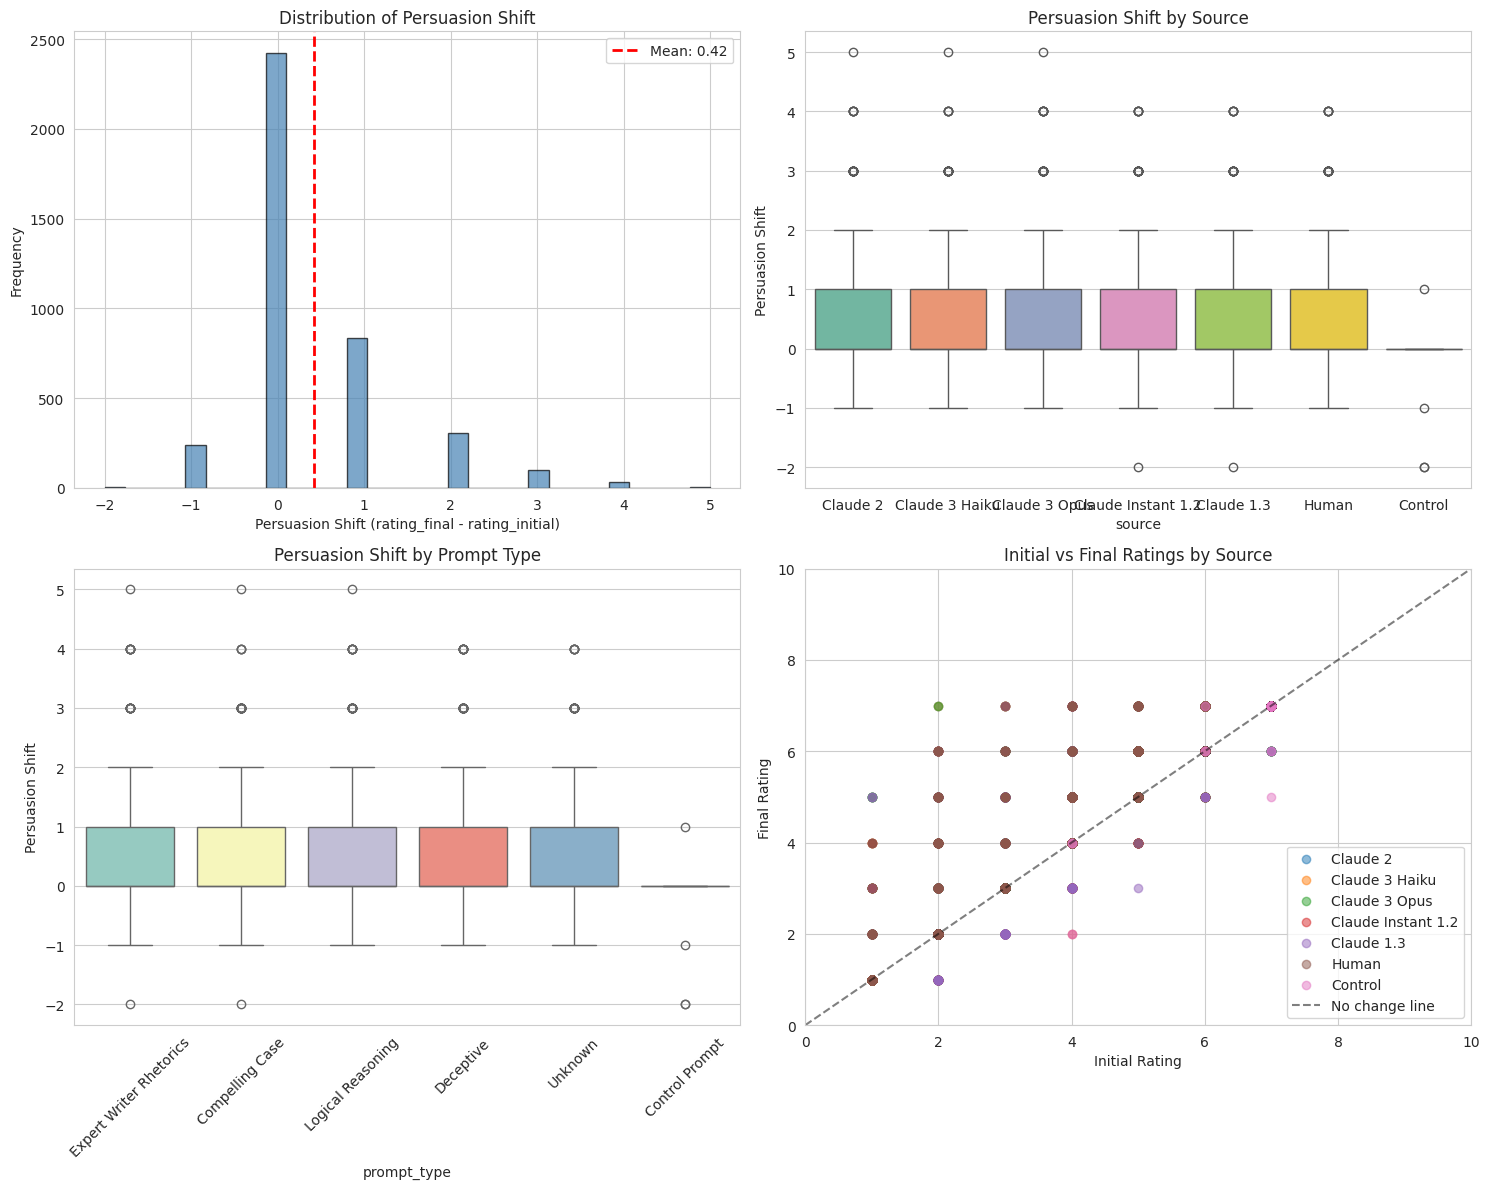

In [7]:
# Visualization 1: Persuasion Shift Distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Distribution of persuasion shift
axes[0, 0].hist(df['persuasion_shift'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df['persuasion_shift'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["persuasion_shift"].mean():.2f}')
axes[0, 0].set_xlabel('Persuasion Shift (rating_final - rating_initial)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Persuasion Shift')
axes[0, 0].legend()

# Persuasion shift by source
sns.boxplot(data=df, x='source', y='persuasion_shift', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Persuasion Shift by Source')
axes[0, 1].set_ylabel('Persuasion Shift')

# Persuasion shift by prompt type
sns.boxplot(data=df, x='prompt_type', y='persuasion_shift', ax=axes[1, 0], palette='Set3')
axes[1, 0].set_title('Persuasion Shift by Prompt Type')
axes[1, 0].set_ylabel('Persuasion Shift')
axes[1, 0].tick_params(axis='x', rotation=45)

# Initial vs Final ratings by source
for source in df['source'].unique():
    subset = df[df['source'] == source]
    axes[1, 1].scatter(subset['rating_initial'], subset['rating_final'], label=source, alpha=0.5)
axes[1, 1].plot([0, 10], [0, 10], 'k--', alpha=0.5, label='No change line')
axes[1, 1].set_xlabel('Initial Rating')
axes[1, 1].set_ylabel('Final Rating')
axes[1, 1].set_title('Initial vs Final Ratings by Source')
axes[1, 1].legend()
axes[1, 1].set_xlim(0, 10)
axes[1, 1].set_ylim(0, 10)

plt.tight_layout()
plt.show()

In [8]:
# OBJECTIVE 2: Identify Features that Drive Persuasion
print("OBJECTIVE 2: IDENTIFY FEATURES DRIVING PERSUASION")

# Extract text features
print("\nExtracting textual features from arguments...")

# Calculate text-based features
df['argument_length'] = df['argument'].str.len()
df['argument_word_count'] = df['argument'].str.split().str.len()
df['argument_sentence_count'] = df['argument'].str.split('.').str.len()
df['avg_sentence_length'] = df['argument_word_count'] / df['argument_sentence_count']

# Calculate sentiment/lexical features (simple proxy using presence of certain words)
emotion_words = r'(amazing|terrible|wonderful|horrible|love|hate|excellent|awful)'
df['emotion_word_count'] = df['argument'].str.lower().str.count(emotion_words)

evidence_markers = r'(research|study|data|evidence|shows|proves|according|found|report)'
df['evidence_marker_count'] = df['argument'].str.lower().str.count(evidence_markers)

question_mark_count = r'\?'
df['question_count'] = df['argument'].str.count(question_mark_count)

print("\nText Features Summary:")
text_features = ['argument_length', 'argument_word_count', 'argument_sentence_count',
                 'avg_sentence_length', 'emotion_word_count', 'evidence_marker_count', 'question_count']
df[text_features].describe().round(2)

OBJECTIVE 2: IDENTIFY FEATURES DRIVING PERSUASION

Extracting textual features from arguments...

Text Features Summary:


,argument_length,argument_word_count,argument_sentence_count,avg_sentence_length,emotion_word_count,evidence_marker_count,question_count
count,3939.00,3939.00,3939.00,3939.00,3939.00,3939.00,3939.00
mean,1608.70,243.87,13.85,18.14,0.15,1.25,0.24
std,234.26,35.61,2.86,3.60,0.48,1.68,0.79
min,1013.00,142.00,7.00,8.00,0.00,0.00,0.00
25%,1457.00,222.00,12.00,15.64,0.00,0.00,0.00
50%,1598.00,243.00,14.00,17.91,0.00,1.00,0.00
75%,1752.00,265.00,15.00,20.38,0.00,2.00,0.00
max,2583.00,398.00,28.00,33.33,4.00,12.00,11.00




Correlation with Final Rating:
rating_final               1.000000
rating_initial             0.888390
persuasion_shift           0.301122
evidence_marker_count      0.042049
emotion_word_count         0.028552
argument_word_count        0.028010
argument_sentence_count    0.017312
argument_length            0.010474
avg_sentence_length        0.004594
question_count            -0.027935
Name: rating_final, dtype: float64


Correlation with Persuasion Shift:
persuasion_shift           1.000000
rating_final               0.301122
argument_length            0.047131
argument_word_count        0.026899
evidence_marker_count      0.015595
argument_sentence_count    0.011269
avg_sentence_length        0.002331
emotion_word_count        -0.033732
question_count            -0.035872
rating_initial            -0.170268
Name: persuasion_shift, dtype: float64


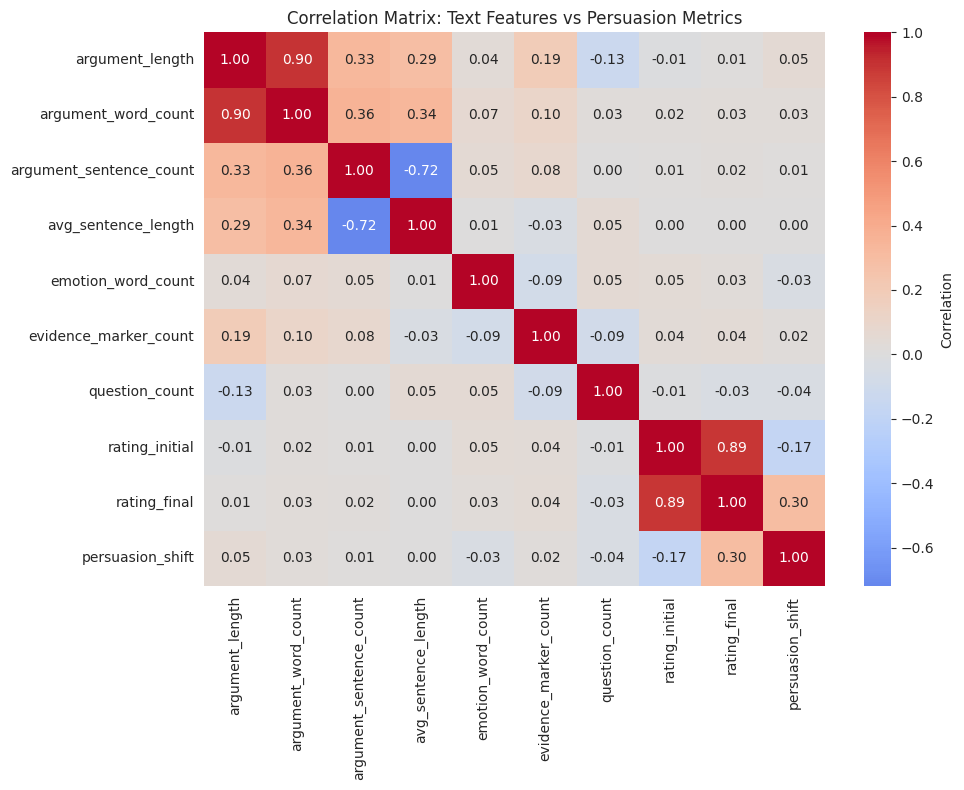

In [9]:
# Correlation Analysis: Features vs Final Ratings
print("\n\nCorrelation with Final Rating:")
correlation_features = text_features + ['rating_initial', 'rating_final', 'persuasion_shift']
correlation_matrix = df[correlation_features].corr()
print(correlation_matrix['rating_final'].sort_values(ascending=False))

print("\n\nCorrelation with Persuasion Shift:")
print(correlation_matrix['persuasion_shift'].sort_values(ascending=False))

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix: Text Features vs Persuasion Metrics')
plt.tight_layout()
plt.show()

In [10]:
# Regression Analysis: What Predicts Final Rating?
print("\n\nRegression Analysis: Features Predicting Final Rating")
print("-" * 60)

# Prepare data for regression
regression_features = text_features + ['rating_initial']
X_reg = df[regression_features].copy()
y_reg = df['rating_final'].copy()

# Standardize features for interpretation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reg)

# Linear Regression with statsmodels for statistical significance
X_with_const = sm.add_constant(X_scaled)
model_ols = sm.OLS(y_reg, X_with_const).fit()
print(model_ols.summary())

# Store feature importance
feature_importance_lr = pd.DataFrame({
    'feature': regression_features,
    'coefficient': model_ols.params[1:].values,
    'std_error': model_ols.bse[1:].values,
    't_stat': model_ols.tvalues[1:].values,
    'p_value': model_ols.pvalues[1:].values
}).sort_values('p_value')

print("\n\nSignificant Features (p < 0.05):")
print(feature_importance_lr[feature_importance_lr['p_value'] < 0.05])



Regression Analysis: Features Predicting Final Rating
------------------------------------------------------------
                            OLS Regression Results                            
Dep. Variable:           rating_final   R-squared:                       0.790
Model:                            OLS   Adj. R-squared:                  0.790
Method:                 Least Squares   F-statistic:                     1849.
Date:                Sat, 11 Apr 2026   Prob (F-statistic):               0.00
Time:                        21:23:39   Log-Likelihood:                -5052.6
No. Observations:                3939   AIC:                         1.012e+04
Df Residuals:                    3930   BIC:                         1.018e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------



Random Forest Feature Importance for Final Rating Prediction
------------------------------------------------------------
                   feature  importance
7           rating_initial    0.811993
0          argument_length    0.059027
3      avg_sentence_length    0.047210
1      argument_word_count    0.041614
5    evidence_marker_count    0.016036
2  argument_sentence_count    0.013346
6           question_count    0.005774
4       emotion_word_count    0.005001


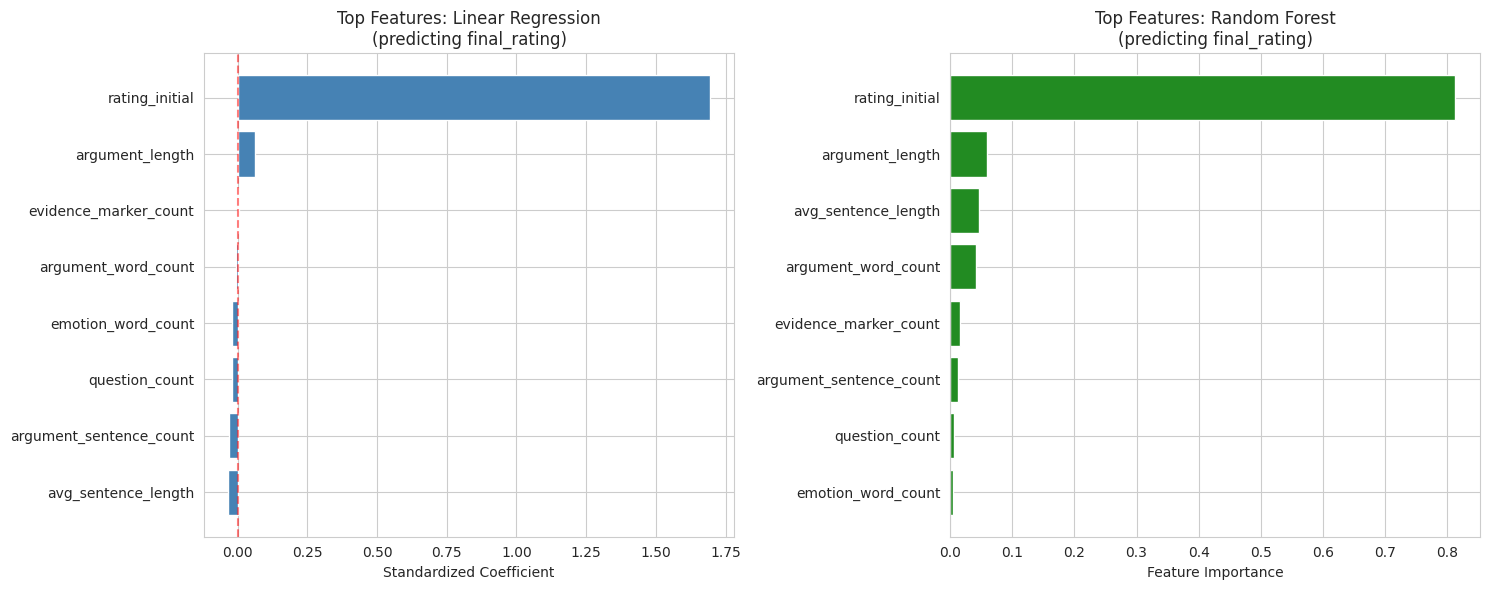

In [11]:
# Random Forest for Feature Importance
print("\n\nRandom Forest Feature Importance for Final Rating Prediction")
print("-" * 60)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_reg, y_reg)

feature_importance_rf = pd.DataFrame({
    'feature': regression_features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance_rf)

# Visualize feature importance
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Linear Regression Coefficients
top_features_lr = feature_importance_lr.head(10).sort_values('coefficient')
axes[0].barh(top_features_lr['feature'], top_features_lr['coefficient'], color='steelblue')
axes[0].set_xlabel('Standardized Coefficient')
axes[0].set_title('Top Features: Linear Regression\n(predicting final_rating)')
axes[0].axvline(x=0, color='red', linestyle='--', alpha=0.5)

# Random Forest Importance
top_features_rf = feature_importance_rf.head(10).sort_values('importance')
axes[1].barh(top_features_rf['feature'], top_features_rf['importance'], color='forestgreen')
axes[1].set_xlabel('Feature Importance')
axes[1].set_title('Top Features: Random Forest\n(predicting final_rating)')

plt.tight_layout()
plt.show()

In [12]:
# Regression Analysis: What Predicts Persuasion Shift?
print("\n\nRegression Analysis: Features Predicting Persuasion Shift (persuasion_shift)")
print("-" * 60)

y_shift = df['persuasion_shift'].copy()
X_with_const_shift = sm.add_constant(X_scaled)
model_shift = sm.OLS(y_shift, X_with_const_shift).fit()
print(model_shift.summary())

# Feature importance for persuasion shift
feature_importance_shift = pd.DataFrame({
    'feature': regression_features,
    'coefficient': model_shift.params[1:].values,
    'std_error': model_shift.bse[1:].values,
    'p_value': model_shift.pvalues[1:].values
}).sort_values('p_value')

print("\n\nSignificant Features for Persuasion Shift (p < 0.05):")
print(feature_importance_shift[feature_importance_shift['p_value'] < 0.05])



Regression Analysis: Features Predicting Persuasion Shift (persuasion_shift)
------------------------------------------------------------
                            OLS Regression Results                            
Dep. Variable:       persuasion_shift   R-squared:                       0.033
Model:                            OLS   Adj. R-squared:                  0.031
Method:                 Least Squares   F-statistic:                     16.82
Date:                Sat, 11 Apr 2026   Prob (F-statistic):           9.02e-25
Time:                        21:23:42   Log-Likelihood:                -5052.6
No. Observations:                3939   AIC:                         1.012e+04
Df Residuals:                    3930   BIC:                         1.018e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025    

In [13]:
# OBJECTIVE 3: Compare Prompting Strategies
print("\n" + "="*80)
print("OBJECTIVE 3: COMPARE PROMPTING STRATEGIES")
print("="*80)

# Statistical comparison of prompt types
print("\n\nPrompt Type Comparison:")
prompt_comparison = df.groupby('prompt_type').agg({
    'rating_initial': ['mean', 'std', 'count'],
    'rating_final': ['mean', 'std'],
    'persuasion_shift': ['mean', 'std', 'median']
}).round(3)
print(prompt_comparison)

# Two-way ANOVA: Source and Prompt Type effects
print("\n\nTwo-Way ANOVA: Effects of Source and Prompt Type on Final Rating")
print("-" * 60)

formula = 'rating_final ~ C(source) + C(prompt_type) + C(source):C(prompt_type)'
model_anova = ols(formula, data=df).fit()
anova_table = sm.stats.anova_lm(model_anova, typ=2)
print(anova_table)


OBJECTIVE 3: COMPARE PROMPTING STRATEGIES


Prompt Type Comparison:
                        rating_initial              rating_final         \
                                  mean    std count         mean    std   
prompt_type                                                               
Compelling Case                  4.101  1.798   840        4.499  1.895   
Control Prompt                   6.789  0.700    57        6.719  0.901   
Deceptive                        4.168  1.871   840        4.638  1.917   
Expert Writer Rhetorics          4.225  1.763   840        4.527  1.851   
Logical Reasoning                4.148  1.838   840        4.593  1.933   
Unknown                          4.136  1.893   522        4.676  1.895   

                        persuasion_shift                
                                    mean    std median  
prompt_type                                             
Compelling Case                    0.398  0.889    0.0  
Control Prompt             

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 6, but rank is 0
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 5, but rank is 0
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 30, but rank is 14
  warnings.warn('covariance of constraints does not have full '


In [14]:
# Pairwise comparisons between prompt types
print("\n\nPost-hoc Pairwise T-tests: Prompt Type Comparisons")
print("-" * 60)

prompt_types = df['prompt_type'].unique()
pairwise_results = []

for i, prompt1 in enumerate(prompt_types):
    for prompt2 in prompt_types[i+1:]:
        group1 = df[df['prompt_type'] == prompt1]['persuasion_shift']
        group2 = df[df['prompt_type'] == prompt2]['persuasion_shift']

        t_stat, p_val = stats.ttest_ind(group1, group2)
        mean_diff = group1.mean() - group2.mean()

        pairwise_results.append({
            'Comparison': f"{prompt1} vs {prompt2}",
            'Mean_Diff': mean_diff,
            'T_Stat': t_stat,
            'P_Value': p_val,
            'Significant': 'Yes' if p_val < 0.05 else 'No'
        })

pairwise_df = pd.DataFrame(pairwise_results)
print(pairwise_df.to_string(index=False))



Post-hoc Pairwise T-tests: Prompt Type Comparisons
------------------------------------------------------------
                                  Comparison  Mean_Diff    T_Stat      P_Value Significant
  Expert Writer Rhetorics vs Compelling Case  -0.095238 -2.239650 2.524420e-02         Yes
Expert Writer Rhetorics vs Logical Reasoning  -0.142857 -3.335629 8.696357e-04         Yes
        Expert Writer Rhetorics vs Deceptive  -0.167857 -3.889725 1.042756e-04         Yes
          Expert Writer Rhetorics vs Unknown  -0.237849 -4.950095 8.345519e-07         Yes
   Expert Writer Rhetorics vs Control Prompt   0.372556  3.267898 1.124763e-03         Yes
        Compelling Case vs Logical Reasoning  -0.047619 -1.090166 2.757967e-01          No
                Compelling Case vs Deceptive  -0.072619 -1.650411 9.904600e-02          No
                  Compelling Case vs Unknown  -0.142611 -2.894491 3.858336e-03         Yes
           Compelling Case vs Control Prompt   0.467794  3.941554 8

In [15]:
# AI vs Human Effectiveness Comparison
print("\n\nAI vs Human Argument Effectiveness")
print("-" * 60)

ai_sources = df[df['source'].str.contains('claude|gpt|ai', case=False, na=False)]['source'].unique() if any(df['source'].str.contains('claude|gpt|ai', case=False, na=False)) else ['AI (if present)']
human_sources = df[~df['source'].str.contains('claude|gpt|ai', case=False, na=False)]['source'].unique() if any(~df['source'].str.contains('claude|gpt|ai', case=False, na=False)) else ['Human (if present)']

print(f"\nAI Sources: {ai_sources}")
print(f"Human Sources: {human_sources}")

# Create AI/Human grouping
df['source_type'] = df['source'].apply(lambda x: 'AI' if any(ai in x.lower() for ai in ['claude', 'gpt', 'ai']) else 'Human')

print("\nPersuasiveness by Source Type (AI vs Human):")
source_type_comp = df.groupby('source_type').agg({
    'rating_initial': ['mean', 'std'],
    'rating_final': ['mean', 'std'],
    'persuasion_shift': ['mean', 'std', 'median', 'count']
}).round(3)
print(source_type_comp)

# T-test: AI vs Human persuasion shift
ai_shift = df[df['source_type'] == 'AI']['persuasion_shift']
human_shift = df[df['source_type'] == 'Human']['persuasion_shift']

t_stat_ai_human, p_val_ai_human = stats.ttest_ind(ai_shift, human_shift)
print(f"\n\nT-test: AI vs Human Persuasion Shift")
print(f"AI Mean Shift: {ai_shift.mean():.3f}, Human Mean Shift: {human_shift.mean():.3f}")
print(f"T-statistic: {t_stat_ai_human:.3f}, P-value: {p_val_ai_human:.4f}")
print(f"Significant Difference: {'Yes' if p_val_ai_human < 0.05 else 'No'}")



AI vs Human Argument Effectiveness
------------------------------------------------------------

AI Sources: ['Claude 2' 'Claude 3 Haiku' 'Claude 3 Opus' 'Claude Instant 1.2'
 'Claude 1.3']
Human Sources: ['Human' 'Control']

Persuasiveness by Source Type (AI vs Human):
            rating_initial        rating_final        persuasion_shift         \
                      mean    std         mean    std             mean    std   
source_type                                                                     
AI                   4.160  1.818        4.564  1.899            0.404  0.892   
Human                4.397  1.976        4.877  1.920            0.480  0.861   

                          
            median count  
source_type               
AI             0.0  3360  
Human          0.0   579  


T-test: AI vs Human Persuasion Shift
AI Mean Shift: 0.404, Human Mean Shift: 0.480
T-statistic: -1.910, P-value: 0.0562
Significant Difference: No


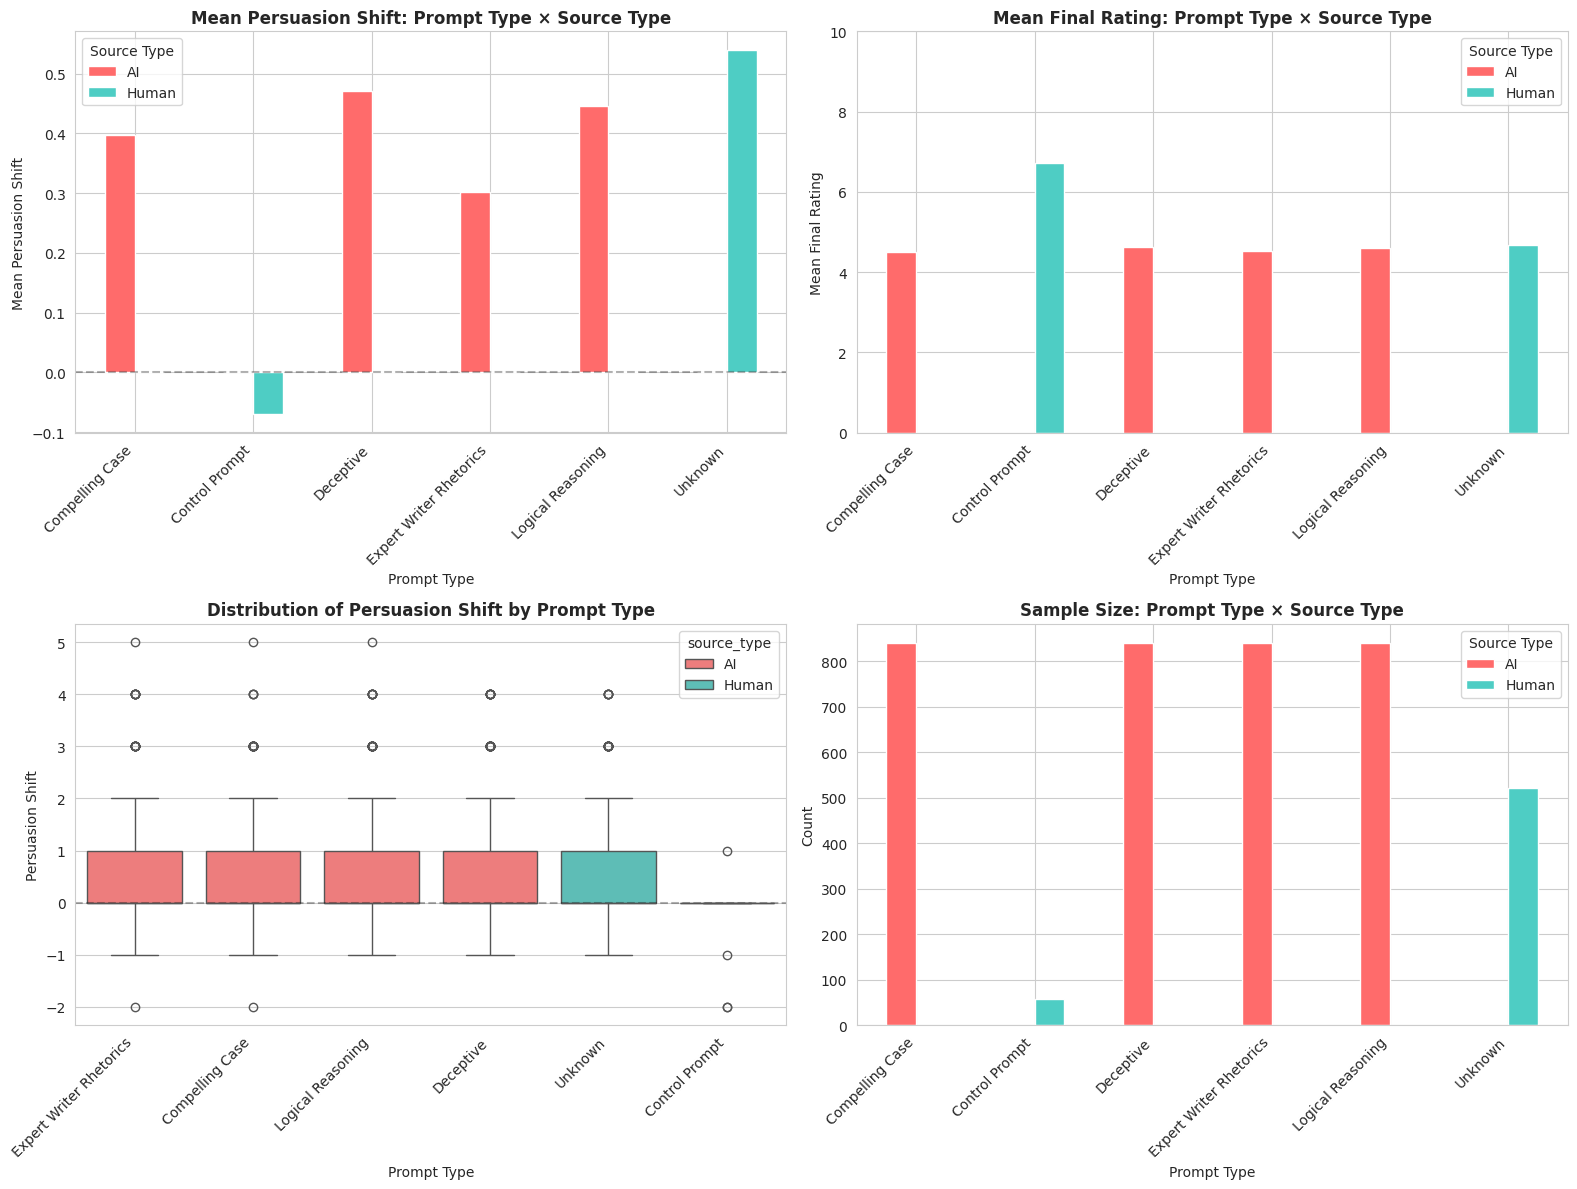

Visualization 2 complete: Strategy comparisons


In [16]:
# Visualization 2: Comparison of Strategies
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Mean persuasion shift by source type and prompt type
pivot_data = df.pivot_table(values='persuasion_shift', index='prompt_type',
                              columns='source_type', aggfunc='mean')
pivot_data.plot(kind='bar', ax=axes[0, 0], color=['#FF6B6B', '#4ECDC4'])
axes[0, 0].set_title('Mean Persuasion Shift: Prompt Type × Source Type', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Mean Persuasion Shift')
axes[0, 0].set_xlabel('Prompt Type')
axes[0, 0].legend(title='Source Type')
axes[0, 0].axhline(y=0, color='black', linestyle='--', alpha=0.3)
plt.setp(axes[0, 0].xaxis.get_majorticklabels(), rotation=45, ha='right')

# 2. Final rating by source type and prompt type
pivot_final = df.pivot_table(values='rating_final', index='prompt_type',
                              columns='source_type', aggfunc='mean')
pivot_final.plot(kind='bar', ax=axes[0, 1], color=['#FF6B6B', '#4ECDC4'])
axes[0, 1].set_title('Mean Final Rating: Prompt Type × Source Type', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Mean Final Rating')
axes[0, 1].set_xlabel('Prompt Type')
axes[0, 1].legend(title='Source Type')
axes[0, 1].set_ylim(0, 10)
plt.setp(axes[0, 1].xaxis.get_majorticklabels(), rotation=45, ha='right')

# 3. Box plot: Persuasion shift by prompt type
sns.boxplot(data=df, x='prompt_type', y='persuasion_shift', hue='source_type', ax=axes[1, 0], palette=['#FF6B6B', '#4ECDC4'])
axes[1, 0].set_title('Distribution of Persuasion Shift by Prompt Type', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Persuasion Shift')
axes[1, 0].set_xlabel('Prompt Type')
axes[1, 0].axhline(y=0, color='black', linestyle='--', alpha=0.3)
plt.setp(axes[1, 0].xaxis.get_majorticklabels(), rotation=45, ha='right')

# 4. Count of observations by source type and prompt type
count_data = df.groupby(['prompt_type', 'source_type']).size().unstack(fill_value=0)
count_data.plot(kind='bar', ax=axes[1, 1], color=['#FF6B6B', '#4ECDC4'])
axes[1, 1].set_title('Sample Size: Prompt Type × Source Type', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_xlabel('Prompt Type')
axes[1, 1].legend(title='Source Type')
plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("Visualization 2 complete: Strategy comparisons")

In [17]:
# ADDRESSING THE RESEARCH QUESTION
print("\n" + "="*80)
print("RESEARCH QUESTION ANALYSIS")
print("="*80)
print("\nRQ: What are the characteristics of claims and arguments that influence their")
print("    initial and final persuasiveness ratings, and how do different prompt types")
print("    and sources affect these metrics?")
print("="*80)

# 1. Characteristics influencing INITIAL ratings
print("\n\n1. CHARACTERISTICS INFLUENCING INITIAL RATINGS:")
print("-" * 60)

# Regression: Initial rating prediction
X_for_initial = df[text_features].copy()
X_scaled_initial = scaler.fit_transform(X_for_initial)
X_with_const_initial = sm.add_constant(X_scaled_initial)
y_initial = df['rating_initial'].copy()

model_initial = sm.OLS(y_initial, X_with_const_initial).fit()

initial_features = pd.DataFrame({
    'feature': text_features,
    'coefficient': model_initial.params[1:].values,
    'p_value': model_initial.pvalues[1:].values
}).sort_values('p_value')

print(f"\nModel R-squared: {model_initial.rsquared:.4f}")
print("\nSignificant features (p < 0.05):")
sig_initial = initial_features[initial_features['p_value'] < 0.05]
if len(sig_initial) > 0:
    print(sig_initial.to_string(index=False))
else:
    print("No significant text features found. Initial ratings may depend on topic/claim not textual characteristics.")


RESEARCH QUESTION ANALYSIS

RQ: What are the characteristics of claims and arguments that influence their
    initial and final persuasiveness ratings, and how do different prompt types
    and sources affect these metrics?


1. CHARACTERISTICS INFLUENCING INITIAL RATINGS:
------------------------------------------------------------

Model R-squared: 0.0103

Significant features (p < 0.05):
              feature  coefficient  p_value
      argument_length    -0.364701 0.000001
evidence_marker_count     0.103824 0.000655
   emotion_word_count     0.085718 0.003691
       question_count    -0.075902 0.015916
  argument_word_count     0.251704 0.023478


In [18]:
# 2. Characteristics influencing FINAL ratings
print("\n\n2. CHARACTERISTICS INFLUENCING FINAL RATINGS:")
print("-" * 60)

final_features = pd.DataFrame({
    'feature': regression_features,
    'coefficient': model_ols.params[1:].values,
    'p_value': model_ols.pvalues[1:].values
}).sort_values('p_value')

print(f"\nModel R-squared: {model_ols.rsquared:.4f}")
print("\nTop features predicting final rating:")
print(final_features.head(10).to_string(index=False))

print("\nInterpretation: Features most strongly influencing final persuasiveness")
print("(Standardized coefficients - effect size when all features at same scale)")
for idx, row in final_features[final_features['p_value'] < 0.05].head(5).iterrows():
    direction = "increases" if row['coefficient'] > 0 else "decreases"
    print(f"  • {row['feature']}: {direction} final rating (p={row['p_value']:.4f})")



2. CHARACTERISTICS INFLUENCING FINAL RATINGS:
------------------------------------------------------------

Model R-squared: 0.7901

Top features predicting final rating:
                feature  coefficient  p_value
         rating_initial     1.694171 0.000000
        argument_length     0.062977 0.078768
     emotion_word_count    -0.021648 0.123655
         question_count    -0.021916 0.143761
    avg_sentence_length    -0.034397 0.527773
argument_sentence_count    -0.030949 0.572476
  evidence_marker_count     0.005356 0.712024
    argument_word_count    -0.006214 0.906474

Interpretation: Features most strongly influencing final persuasiveness
(Standardized coefficients - effect size when all features at same scale)
  • rating_initial: increases final rating (p=0.0000)


In [19]:
# 3. Effect of Prompt Type on Persuasiveness
print("\n\n3. EFFECT OF PROMPT TYPE ON PERSUASIVENESS:")
print("-" * 60)

# ANOVA for prompt type effect
formula_prompt = 'rating_final ~ C(prompt_type)'
model_prompt = ols(formula_prompt, data=df).fit()
anova_prompt = sm.stats.anova_lm(model_prompt, typ=2)

print("\nANOVA: Effect of Prompt Type on Final Rating")
print(anova_prompt)

prompt_effects = df.groupby('prompt_type').agg({
    'rating_final': ['mean', 'std', 'count'],
    'persuasion_shift': ['mean', 'median']
}).round(3)

print("\nPrompt Type Summary:")
print(prompt_effects)

# Find best performing prompt
best_prompt = df.groupby('prompt_type')['persuasion_shift'].mean().idxmax()
print(f"\nBest Performing Prompt Type (highest mean persuasion): {best_prompt}")
print(f"Mean Persuasion Shift: {df.groupby('prompt_type')['persuasion_shift'].mean()[best_prompt]:.3f}")



3. EFFECT OF PROMPT TYPE ON PERSUASIVENESS:
------------------------------------------------------------

ANOVA: Effect of Prompt Type on Final Rating
                      sum_sq      df          F        PR(>F)
C(prompt_type)    272.920173     5.0  15.312448  6.166806e-15
Residual        14019.901355  3933.0        NaN           NaN

Prompt Type Summary:
                        rating_final              persuasion_shift       
                                mean    std count             mean median
prompt_type                                                              
Compelling Case                4.499  1.895   840            0.398    0.0
Control Prompt                 6.719  0.901    57           -0.070    0.0
Deceptive                      4.638  1.917   840            0.470    0.0
Expert Writer Rhetorics        4.527  1.851   840            0.302    0.0
Logical Reasoning              4.593  1.933   840            0.445    0.0
Unknown                        4.676  1.895   5

In [20]:
# 4. Effect of Source (AI vs Human) on Persuasiveness
print("\n\n4. EFFECT OF SOURCE (AI vs HUMAN) ON PERSUASIVENESS:")
print("-" * 60)

# ANOVA for source type effect
formula_source = 'rating_final ~ C(source_type)'
model_source = ols(formula_source, data=df).fit()
anova_source = sm.stats.anova_lm(model_source, typ=2)

print("\nANOVA: Effect of Source Type on Final Rating")
print(anova_source)

source_effects = df.groupby('source_type').agg({
    'rating_initial': ['mean', 'std'],
    'rating_final': ['mean', 'std', 'count'],
    'persuasion_shift': ['mean', 'std', 'median']
}).round(3)

print("\nSource Type Summary:")
print(source_effects)

# Statistical test
print("\nIndependent T-test: AI vs Human")
ai_data = df[df['source_type'] == 'AI']['rating_final']
human_data = df[df['source_type'] == 'Human']['rating_final']

t_stat_final, p_val_final = stats.ttest_ind(ai_data, human_data)
print(f"AI Mean Final Rating: {ai_data.mean():.3f}, Human Mean Final Rating: {human_data.mean():.3f}")
print(f"T-statistic: {t_stat_final:.3f}, P-value: {p_val_final:.4f}")

if p_val_final < 0.05:
    if ai_data.mean() > human_data.mean():
        print("✓ AI arguments achieve significantly HIGHER final ratings than human arguments")
    else:
        print("✓ Human arguments achieve significantly HIGHER final ratings than AI arguments")
else:
    print("No significant difference in final ratings between AI and Human arguments")



4. EFFECT OF SOURCE (AI vs HUMAN) ON PERSUASIVENESS:
------------------------------------------------------------

ANOVA: Effect of Source Type on Final Rating
                      sum_sq      df          F    PR(>F)
C(source_type)     48.413633     1.0  13.381004  0.000258
Residual        14244.407895  3937.0        NaN       NaN

Source Type Summary:
            rating_initial        rating_final              persuasion_shift  \
                      mean    std         mean    std count             mean   
source_type                                                                    
AI                   4.160  1.818        4.564  1.899  3360            0.404   
Human                4.397  1.976        4.877  1.920   579            0.480   

                           
               std median  
source_type                
AI           0.892    0.0  
Human        0.861    0.0  

Independent T-test: AI vs Human
AI Mean Final Rating: 4.564, Human Mean Final Rating: 4.877
T-statis



5. INTERACTION: PROMPT TYPE × SOURCE TYPE
------------------------------------------------------------

Two-way ANOVA with Interaction:
                                     sum_sq      df             F    PR(>F)
C(prompt_type)                 2.703011e-08     5.0  1.514955e-09  1.000000
C(source_type)                          NaN     1.0           NaN       NaN
C(prompt_type):C(source_type)  2.526256e+01     5.0  1.415889e+00  0.234153
Residual                       1.403466e+04  3933.0           NaN       NaN

Interpretation:
✗ NO SIGNIFICANT INTERACTION: Prompt type effects are consistent across sources


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 5, but rank is 2
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 1, but rank is 0
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 5, but rank is 1
  warnings.warn('covariance of constraints does not have full '


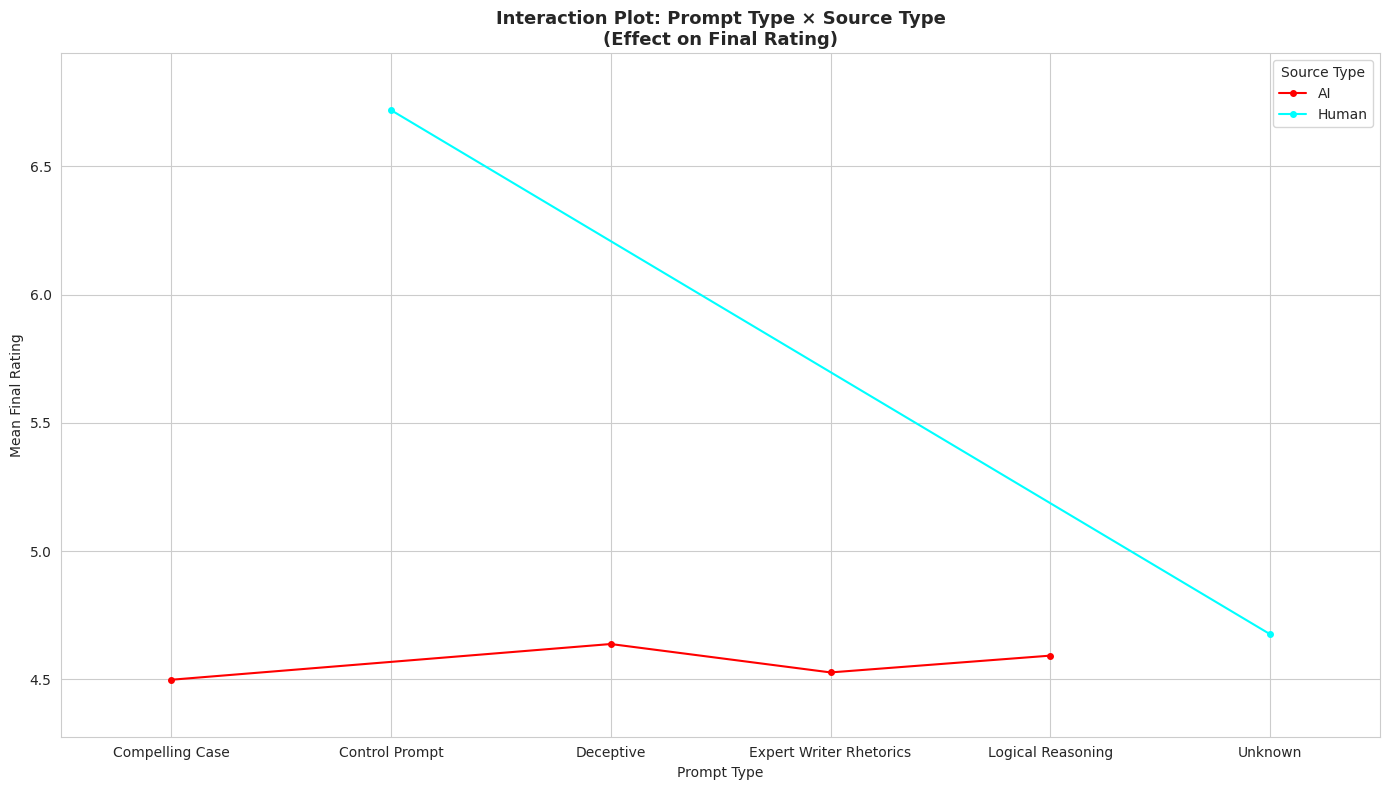

In [21]:
# 5. Interaction: Prompt Type × Source Type
print("\n\n5. INTERACTION: PROMPT TYPE × SOURCE TYPE")
print("-" * 60)

# Two-way ANOVA with interaction
formula_interaction = 'rating_final ~ C(prompt_type) + C(source_type) + C(prompt_type):C(source_type)'
model_interaction = ols(formula_interaction, data=df).fit()
anova_interaction = sm.stats.anova_lm(model_interaction, typ=2)

print("\nTwo-way ANOVA with Interaction:")
print(anova_interaction)

print("\nInterpretation:")
if anova_interaction.loc['C(prompt_type):C(source_type)', 'PR(>F)'] < 0.05:
    print("✓ SIGNIFICANT INTERACTION: The effect of prompt type differs between AI and Human")
    print("  Different prompt types may be optimal for AI vs Human arguments")
else:
    print("✗ NO SIGNIFICANT INTERACTION: Prompt type effects are consistent across sources")

# Create interaction plot
from statsmodels.graphics.factorplots import interaction_plot

interaction_plot(df['prompt_type'], df['source_type'], df['rating_final'],
                 ms=8, ax=plt.gca())
plt.title('Interaction Plot: Prompt Type × Source Type\n(Effect on Final Rating)', fontsize=13, fontweight='bold')
plt.ylabel('Mean Final Rating')
plt.xlabel('Prompt Type')
plt.legend(title='Source Type', loc='best')
plt.tight_layout()
plt.show()

In [22]:
# COMPREHENSIVE SUMMARY & KEY FINDINGS
print("\n" + "="*80)
print("KEY FINDINGS & SUMMARY")
print("="*80)

print("\n📊 DATASET OVERVIEW:")
print(f"  • Total Arguments: {len(df):,}")
print(f"  • Sources: {', '.join(df['source'].unique())}")
print(f"  • Prompt Types: {', '.join(df['prompt_type'].unique())}")
print(f"  • Average Initial Rating: {df['rating_initial'].mean():.2f}/10")
print(f"  • Average Final Rating: {df['rating_final'].mean():.2f}/10")
print(f"  • Average Persuasion Shift: {df['persuasion_shift'].mean():.2f}")

print("\n✅ PERSUASION EFFECTIVENESS:")
print(f"  • Arguments with Positive Persuasion: {(df['persuasion_shift'] > 0).sum()} ({(df['persuasion_shift'] > 0).sum()/len(df)*100:.1f}%)")
print(f"  • Arguments with Negative Persuasion: {(df['persuasion_shift'] < 0).sum()} ({(df['persuasion_shift'] < 0).sum()/len(df)*100:.1f}%)")
print(f"  • Arguments with Minimal Change: {(df['persuasion_shift'].abs() <= 1).sum()} ({(df['persuasion_shift'].abs() <= 1).sum()/len(df)*100:.1f}%)")

print("\n🎯 TOP FEATURES DRIVING PERSUASION (Initial Rating):")
for idx, (i, row) in enumerate(initial_features[initial_features['p_value'] < 0.05].head(3).iterrows(), 1):
    print(f"  {idx}. {row['feature']} (p={row['p_value']:.4f})")

print("\n🎯 TOP FEATURES DRIVING PERSUASION (Final Rating):")
for idx, (i, row) in enumerate(final_features[final_features['p_value'] < 0.05].head(3).iterrows(), 1):
    print(f"  {idx}. {row['feature']} (p={row['p_value']:.4f})")

print("\n🤖 AI vs HUMAN COMPARISON:")
print(f"  • AI Mean Final Rating: {ai_data.mean():.2f}")
print(f"  • Human Mean Final Rating: {human_data.mean():.2f}")
print(f"  • AI Mean Persuasion Shift: {df[df['source_type']=='AI']['persuasion_shift'].mean():.2f}")
print(f"  • Human Mean Persuasion Shift: {df[df['source_type']=='Human']['persuasion_shift'].mean():.2f}")


KEY FINDINGS & SUMMARY

📊 DATASET OVERVIEW:
  • Total Arguments: 3,939
  • Sources: Claude 2, Claude 3 Haiku, Claude 3 Opus, Claude Instant 1.2, Claude 1.3, Human, Control
  • Prompt Types: Expert Writer Rhetorics, Compelling Case, Logical Reasoning, Deceptive, Unknown, Control Prompt
  • Average Initial Rating: 4.20/10
  • Average Final Rating: 4.61/10
  • Average Persuasion Shift: 0.42

✅ PERSUASION EFFECTIVENESS:
  • Arguments with Positive Persuasion: 1273 (32.3%)
  • Arguments with Negative Persuasion: 244 (6.2%)
  • Arguments with Minimal Change: 3496 (88.8%)

🎯 TOP FEATURES DRIVING PERSUASION (Initial Rating):
  1. argument_length (p=0.0000)
  2. evidence_marker_count (p=0.0007)
  3. emotion_word_count (p=0.0037)

🎯 TOP FEATURES DRIVING PERSUASION (Final Rating):
  1. rating_initial (p=0.0000)

🤖 AI vs HUMAN COMPARISON:
  • AI Mean Final Rating: 4.56
  • Human Mean Final Rating: 4.88
  • AI Mean Persuasion Shift: 0.40
  • Human Mean Persuasion Shift: 0.48


In [23]:
print("\n💡 PROMPT TYPE EFFECTIVENESS:")
best_prompt_shift = df.groupby('prompt_type')['persuasion_shift'].mean()
print(f"  Best Prompt Type: {best_prompt_shift.idxmax()} (Avg Shift: {best_prompt_shift.max():.3f})")
for prompt_type in df['prompt_type'].unique():
    shift = df[df['prompt_type'] == prompt_type]['persuasion_shift'].mean()
    final = df[df['prompt_type'] == prompt_type]['rating_final'].mean()
    print(f"    • {prompt_type}: Final Rating={final:.2f}, Shift={shift:.3f}")

print("\n🔄 INTERACTION EFFECTS:")
if anova_interaction.loc['C(prompt_type):C(source_type)', 'PR(>F)'] < 0.05:
    print("  ✓ Significant prompt type × source type interaction detected")
    print("    → Different prompts work better for AI vs Human")
else:
    print("  ✗ No significant prompt type × source type interaction")
    print("    → Prompt effectiveness is consistent across sources")

print("\n📈 MODEL PERFORMANCE:")
print(f"  • Model R² (Final Rating): {model_ols.rsquared:.4f}")
print(f"  • Model R² (Persuasion Shift): {model_shift.rsquared:.4f}")
print(f"  • Random Forest R² (Final Rating): {rf_model.score(X_reg, y_reg):.4f}")

print("\n" + "="*80)


💡 PROMPT TYPE EFFECTIVENESS:
  Best Prompt Type: Unknown (Avg Shift: 0.540)
    • Expert Writer Rhetorics: Final Rating=4.53, Shift=0.302
    • Compelling Case: Final Rating=4.50, Shift=0.398
    • Logical Reasoning: Final Rating=4.59, Shift=0.445
    • Deceptive: Final Rating=4.64, Shift=0.470
    • Unknown: Final Rating=4.68, Shift=0.540
    • Control Prompt: Final Rating=6.72, Shift=-0.070

🔄 INTERACTION EFFECTS:
  ✗ No significant prompt type × source type interaction
    → Prompt effectiveness is consistent across sources

📈 MODEL PERFORMANCE:
  • Model R² (Final Rating): 0.7901
  • Model R² (Persuasion Shift): 0.0331
  • Random Forest R² (Final Rating): 0.9449



In [24]:
# ADVANCED ANALYSIS: Identify optimal argument profiles
print("\nADVANCED ANALYSIS: OPTIMAL ARGUMENT PROFILES")
print("="*80)

# Find highly persuasive arguments (high shift, starting from neutral/opposed)
high_persuasion = df[(df['persuasion_shift'] > df['persuasion_shift'].quantile(0.75)) &
                     (df['rating_initial'] < 5)].copy()

low_persuasion = df[(df['persuasion_shift'] < df['persuasion_shift'].quantile(0.25)) &
                    (df['rating_initial'] > 5)].copy()

print(f"\nHigh Persuasion Arguments (n={len(high_persuasion)}):")
print(f"  • Avg Initial Rating: {high_persuasion['rating_initial'].mean():.2f}")
print(f"  • Avg Final Rating: {high_persuasion['rating_final'].mean():.2f}")
print(f"  • Avg Persuasion Shift: {high_persuasion['persuasion_shift'].mean():.2f}")
print("\n  Characteristics:")
for feature in text_features:
    hp_mean = high_persuasion[feature].mean()
    overall_mean = df[feature].mean()
    diff = ((hp_mean - overall_mean) / overall_mean * 100) if overall_mean != 0 else 0
    print(f"    • {feature}: {hp_mean:.2f} ({diff:+.1f}% vs average)")

print(f"\n\nLow Persuasion Arguments (n={len(low_persuasion)}):")
print(f"  • Avg Initial Rating: {low_persuasion['rating_initial'].mean():.2f}")
print(f"  • Avg Final Rating: {low_persuasion['rating_final'].mean():.2f}")
print(f"  • Avg Persuasion Shift: {low_persuasion['persuasion_shift'].mean():.2f}")
print("\n  Characteristics:")
for feature in text_features:
    lp_mean = low_persuasion[feature].mean()
    overall_mean = df[feature].mean()
    diff = ((lp_mean - overall_mean) / overall_mean * 100) if overall_mean != 0 else 0
    print(f"    • {feature}: {lp_mean:.2f} ({diff:+.1f}% vs average)")


ADVANCED ANALYSIS: OPTIMAL ARGUMENT PROFILES

High Persuasion Arguments (n=380):
  • Avg Initial Rating: 2.94
  • Avg Final Rating: 5.39
  • Avg Persuasion Shift: 2.45

  Characteristics:
    • argument_length: 1630.47 (+1.4% vs average)
    • argument_word_count: 245.13 (+0.5% vs average)
    • argument_sentence_count: 13.99 (+1.0% vs average)
    • avg_sentence_length: 17.95 (-1.0% vs average)
    • emotion_word_count: 0.13 (-12.3% vs average)
    • evidence_marker_count: 1.24 (-0.2% vs average)
    • question_count: 0.17 (-28.2% vs average)


Low Persuasion Arguments (n=41):
  • Avg Initial Rating: 6.37
  • Avg Final Rating: 5.34
  • Avg Persuasion Shift: -1.02

  Characteristics:
    • argument_length: 1614.56 (+0.4% vs average)
    • argument_word_count: 244.41 (+0.2% vs average)
    • argument_sentence_count: 14.59 (+5.3% vs average)
    • avg_sentence_length: 17.23 (-5.0% vs average)
    • emotion_word_count: 0.32 (+111.3% vs average)
    • evidence_marker_count: 1.46 (+17.4% v

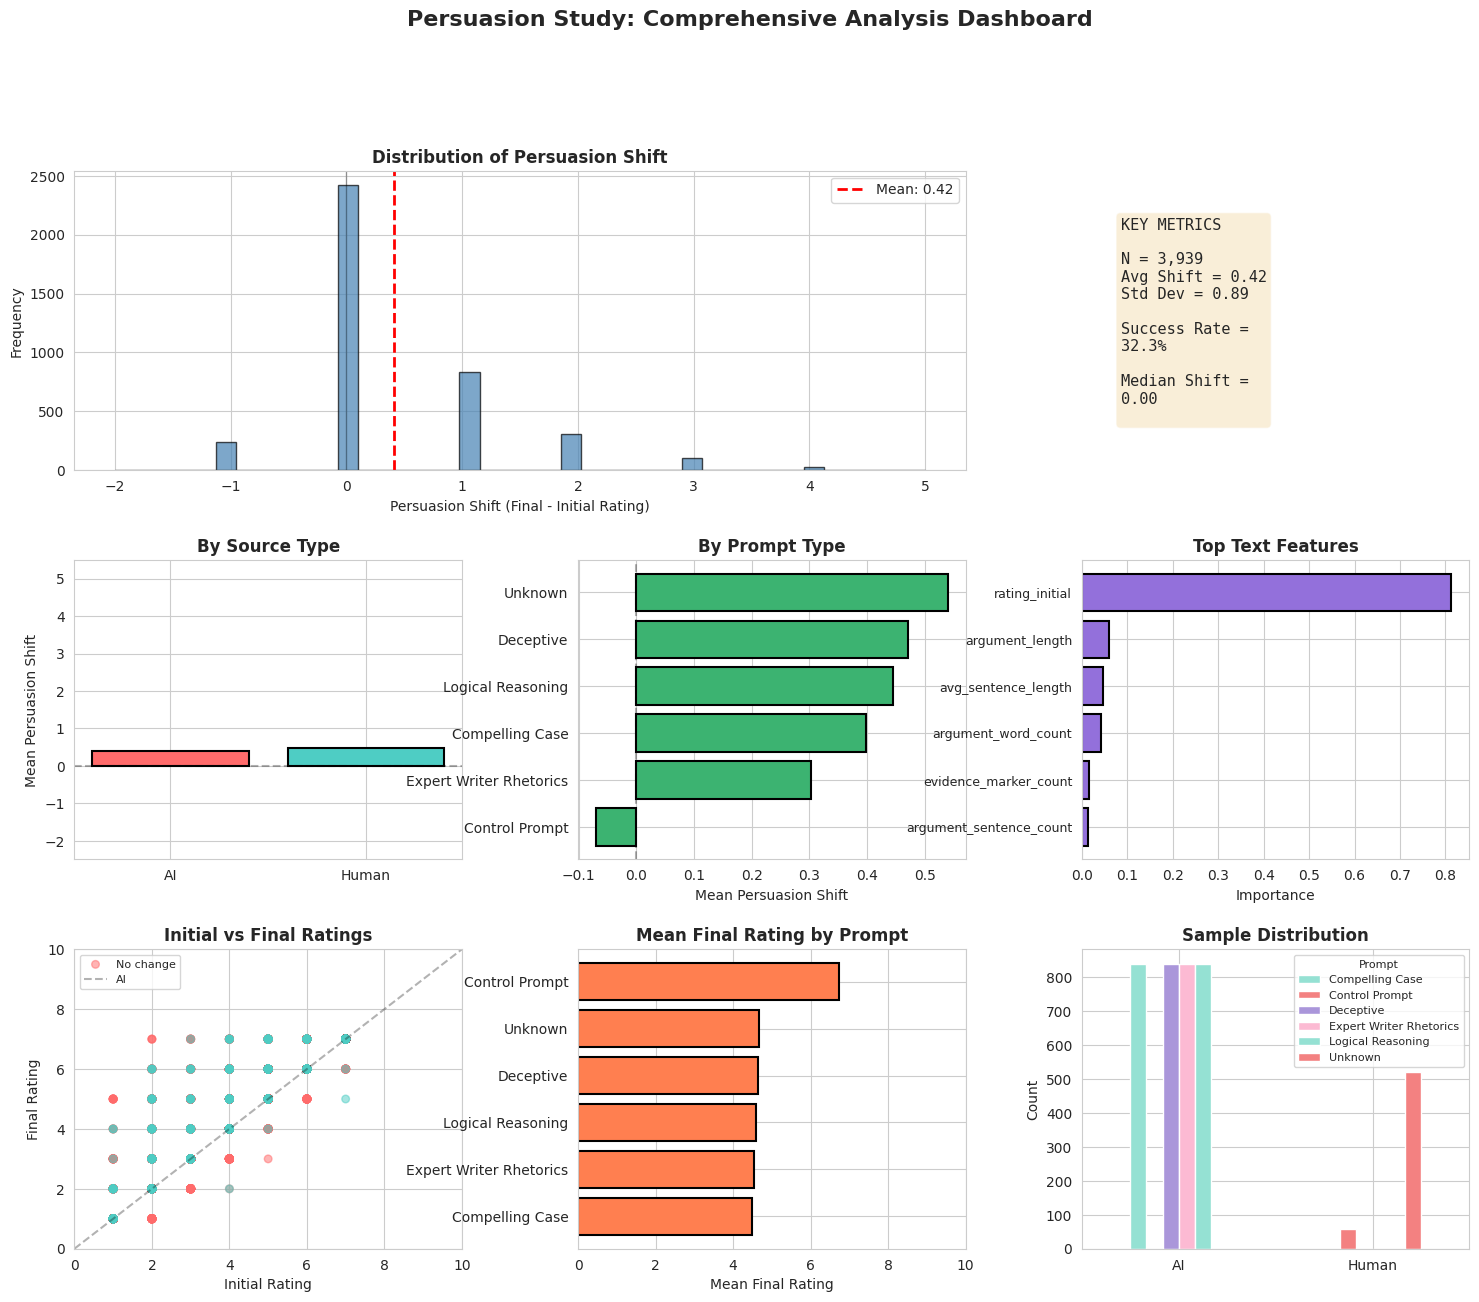


✅ Comprehensive analysis complete!
All visualizations and statistical tests have been generated.


In [25]:
# FINAL VISUALIZATION: Comprehensive Summary Dashboard
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Persuasion Shift Distribution (main)
ax1 = fig.add_subplot(gs[0, :2])
ax1.hist(df['persuasion_shift'], bins=40, color='steelblue', edgecolor='black', alpha=0.7)
ax1.axvline(df['persuasion_shift'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {df["persuasion_shift"].mean():.2f}')
ax1.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.3)
ax1.set_xlabel('Persuasion Shift (Final - Initial Rating)')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Persuasion Shift', fontweight='bold')
ax1.legend()

# 2. Key Metrics Box
ax2 = fig.add_subplot(gs[0, 2])
ax2.axis('off')
metrics_text = f"""KEY METRICS

N = {len(df):,}
Avg Shift = {df['persuasion_shift'].mean():.2f}
Std Dev = {df['persuasion_shift'].std():.2f}

Success Rate =
{(df['persuasion_shift'] > 0).sum()/len(df)*100:.1f}%

Median Shift =
{df['persuasion_shift'].median():.2f}
"""
ax2.text(0.1, 0.5, metrics_text, fontsize=11, verticalalignment='center',
         family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 3. Persuasion by Source
ax3 = fig.add_subplot(gs[1, 0])
source_means = df.groupby('source_type')['persuasion_shift'].mean()
ax3.bar(source_means.index, source_means.values, color=['#FF6B6B', '#4ECDC4'], edgecolor='black', linewidth=1.5)
ax3.set_ylabel('Mean Persuasion Shift')
ax3.set_title('By Source Type', fontweight='bold')
ax3.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax3.set_ylim(df['persuasion_shift'].min()-0.5, df['persuasion_shift'].max()+0.5)

# 4. Persuasion by Prompt
ax4 = fig.add_subplot(gs[1, 1])
prompt_means = df.groupby('prompt_type')['persuasion_shift'].mean().sort_values()
ax4.barh(range(len(prompt_means)), prompt_means.values, color='mediumseagreen', edgecolor='black', linewidth=1.5)
ax4.set_yticks(range(len(prompt_means)))
ax4.set_yticklabels(prompt_means.index)
ax4.set_xlabel('Mean Persuasion Shift')
ax4.set_title('By Prompt Type', fontweight='bold')
ax4.axvline(x=0, color='black', linestyle='--', alpha=0.3)

# 5. Feature Importance
ax5 = fig.add_subplot(gs[1, 2])
top_features_plot = feature_importance_rf.head(6).sort_values('importance')
ax5.barh(range(len(top_features_plot)), top_features_plot['importance'].values,
         color='mediumpurple', edgecolor='black', linewidth=1.5)
ax5.set_yticks(range(len(top_features_plot)))
ax5.set_yticklabels(top_features_plot['feature'].values, fontsize=9)
ax5.set_xlabel('Importance')
ax5.set_title('Top Text Features', fontweight='bold')

# 6. Rating Change Scatter
ax6 = fig.add_subplot(gs[2, 0])
colors = ['#FF6B6B' if s == 'AI' else '#4ECDC4' for s in df['source_type']]
ax6.scatter(df['rating_initial'], df['rating_final'], c=colors, alpha=0.5, s=30)
ax6.plot([0, 10], [0, 10], 'k--', alpha=0.3, label='No change')
ax6.set_xlabel('Initial Rating')
ax6.set_ylabel('Final Rating')
ax6.set_title('Initial vs Final Ratings', fontweight='bold')
ax6.set_xlim(0, 10)
ax6.set_ylim(0, 10)
ax6.legend(['No change', 'AI', 'Human'], fontsize=8)

# 7. Prompt Type Effectiveness
ax7 = fig.add_subplot(gs[2, 1])
prompt_final = df.groupby('prompt_type')['rating_final'].mean().sort_values()
ax7.barh(range(len(prompt_final)), prompt_final.values, color='coral', edgecolor='black', linewidth=1.5)
ax7.set_yticks(range(len(prompt_final)))
ax7.set_yticklabels(prompt_final.index)
ax7.set_xlabel('Mean Final Rating')
ax7.set_title('Mean Final Rating by Prompt', fontweight='bold')
ax7.set_xlim(0, 10)

# 8. Sample Distribution
ax8 = fig.add_subplot(gs[2, 2])
combo_counts = df.groupby(['source_type', 'prompt_type']).size().unstack(fill_value=0)
combo_counts.plot(kind='bar', ax=ax8, color=['#95E1D3', '#F38181', '#AA96DA', '#FCBAD3'])
ax8.set_ylabel('Count')
ax8.set_xlabel('')
ax8.set_title('Sample Distribution', fontweight='bold')
ax8.legend(title='Prompt', fontsize=8, title_fontsize=8)
plt.setp(ax8.xaxis.get_majorticklabels(), rotation=0)

plt.suptitle('Persuasion Study: Comprehensive Analysis Dashboard', fontsize=16, fontweight='bold', y=0.995)
plt.show()

print("\n✅ Comprehensive analysis complete!")
print("All visualizations and statistical tests have been generated.")

EDA EXTENSION 1: CLAIM / TOPIC DISTRIBUTION

Top 20 most frequent claims:
claim
People receiving welfare benefits should be tracked to prevent fraud/abuse.                  78
Tracking welfare recipients violates privacy and harms vulnerable populations.               78
Governments and technology companies must do more to protect online privacy and security.    69
Employers should be allowed to monitor employees through tracking mechanisms.                69
Requiring all police officers to wear body cameras should not be mandated                    69
Self-driving cars will increase safety and should replace human drivers.                     69
Drug importation jeopardizes safety controls and the domestic pharma industry.               69
College athletes should not be paid salaries                                                 69
The US should ban all cultured or lab-grown meat products                                    69
Cultured/lab-grown meats should be allowed to be sold   

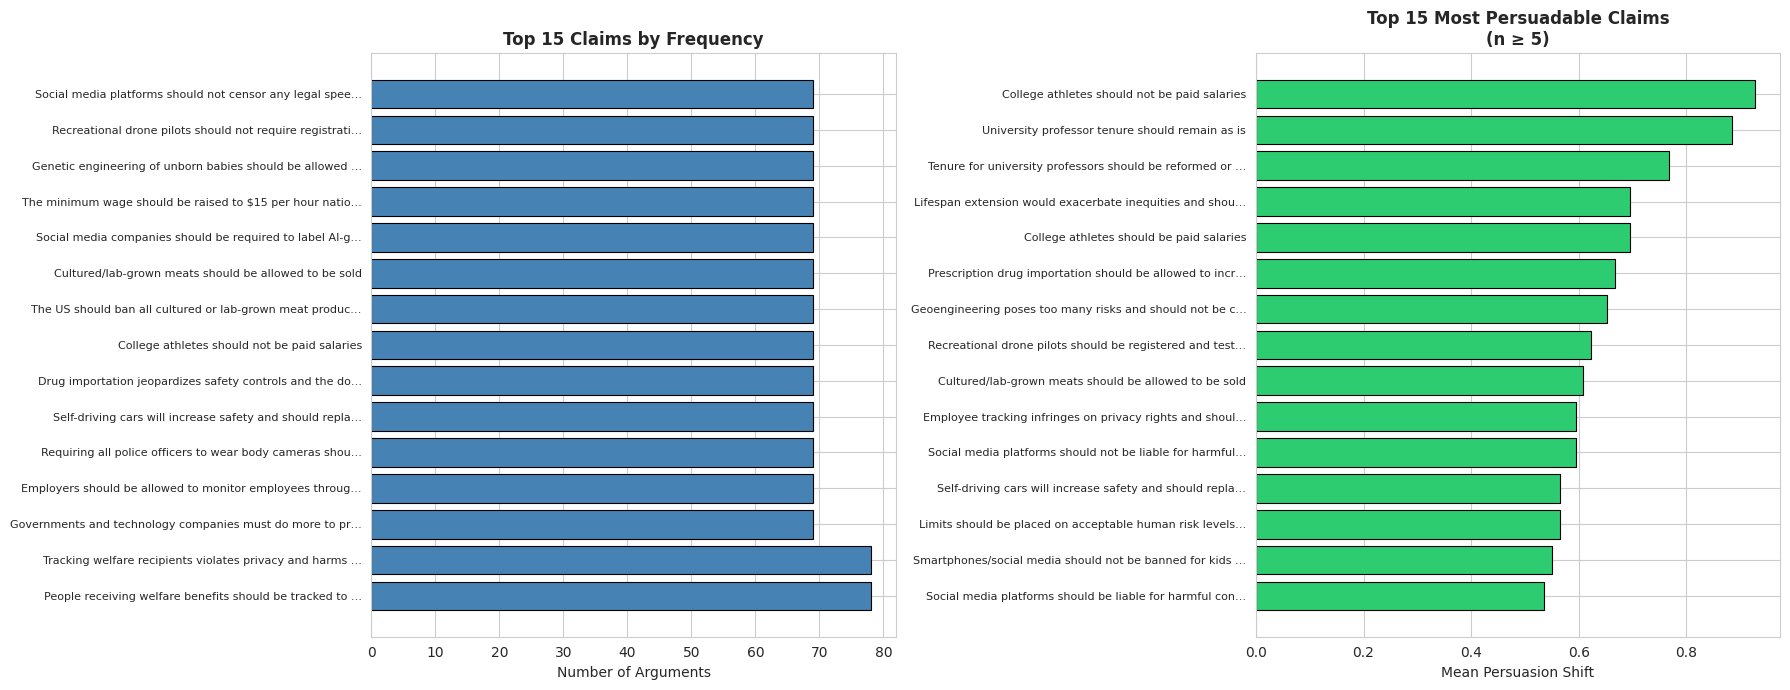

In [26]:
# EDA EXTENSION 1: Claim / Topic Distribution
print("EDA EXTENSION 1: CLAIM / TOPIC DISTRIBUTION")
print("=" * 70)

# --- 1a. Which claims appear in the dataset? ---
print("\nTop 20 most frequent claims:")
claim_counts = df['claim'].value_counts().head(20)
print(claim_counts.to_string())

print(f"\nTotal unique claims: {df['claim'].nunique()}")

# --- 1b. Mean persuasion shift per claim (top 15 most persuadable) ---
claim_persuasion = (
    df.groupby('claim')
      .agg(mean_shift=('persuasion_shift', 'mean'),
           mean_initial=('rating_initial', 'mean'),
           mean_final=('rating_final', 'mean'),
           count=('persuasion_shift', 'count'))
      .query('count >= 5')           # require at least 5 observations
      .sort_values('mean_shift', ascending=False)
)

print("\nTop 10 most persuadable claims (mean shift, n≥5):")
print(claim_persuasion.head(10).round(3).to_string())
print("\nBottom 10 least persuadable / most back-fired claims:")
print(claim_persuasion.tail(10).round(3).to_string())

# --- 1c. Visualise ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: top 15 claims by count
top_claims = claim_counts.head(15)
axes[0].barh(range(len(top_claims)), top_claims.values, color='steelblue', edgecolor='black', linewidth=0.8)
axes[0].set_yticks(range(len(top_claims)))
axes[0].set_yticklabels(
    [c[:55] + '…' if len(c) > 55 else c for c in top_claims.index],
    fontsize=8
)
axes[0].set_xlabel('Number of Arguments')
axes[0].set_title('Top 15 Claims by Frequency', fontweight='bold')

# Right: top 15 claims by mean persuasion shift (min 5 obs)
top_persuadable = claim_persuasion.head(15).sort_values('mean_shift')
bar_colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in top_persuadable['mean_shift']]
axes[1].barh(range(len(top_persuadable)), top_persuadable['mean_shift'].values,
             color=bar_colors, edgecolor='black', linewidth=0.8)
axes[1].set_yticks(range(len(top_persuadable)))
axes[1].set_yticklabels(
    [c[:55] + '…' if len(c) > 55 else c for c in top_persuadable.index],
    fontsize=8
)
axes[1].set_xlabel('Mean Persuasion Shift')
axes[1].set_title('Top 15 Most Persuadable Claims\n(n ≥ 5)', fontweight='bold')
axes[1].axvline(x=0, color='black', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

EDA EXTENSION 2: INITIAL RATING SEGMENT ANALYSIS

Persuasion Statistics by Initial Stance Segment:
                        count  mean_shift  median_shift  std_shift  pct_persuaded  pct_backfired
initial_segment                                                                                 
Strongly Opposed (1-2)    907       0.533           0.0      1.096         31.312          4.961
Opposed (3-4)            1240       0.556           0.0      1.038         41.774         10.806
Neutral (4-5)             630       0.532           0.0      0.721         47.778          3.810
Supportive (6-7)         1162       0.110           0.0      0.415         14.630          3.528

Kruskal-Wallis H=196.592, p=0.0000
→ Initial stance groups differ significantly? YES


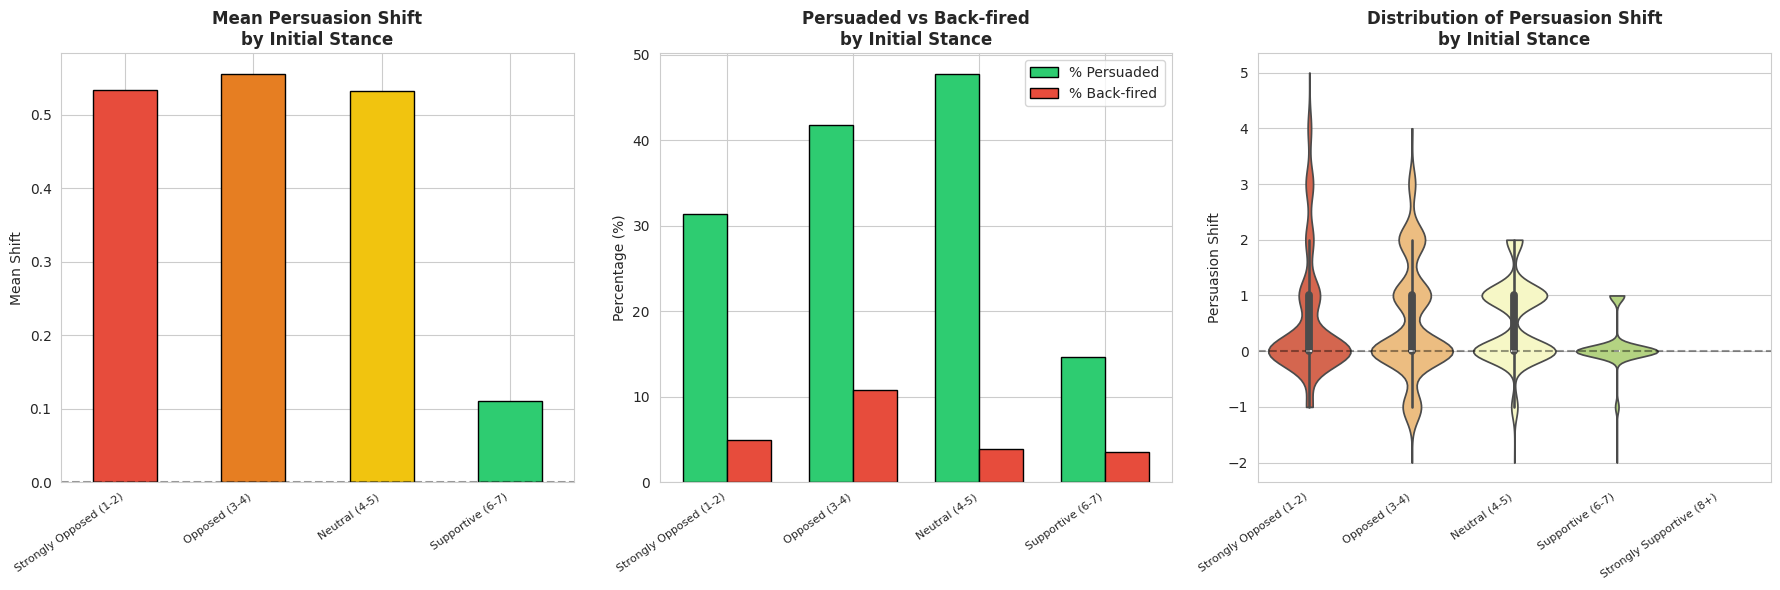

In [27]:
# EDA EXTENSION 2: Initial Rating Segment Analysis
# (Does starting stance affect how much someone can be persuaded?)
print("EDA EXTENSION 2: INITIAL RATING SEGMENT ANALYSIS")
print("=" * 70)

# Define segments based on initial stance
bins   = [0, 2, 4, 5, 7, 8]
labels = ['Strongly Opposed (1-2)',
          'Opposed (3-4)',
          'Neutral (4-5)',
          'Supportive (6-7)',
          'Strongly Supportive (8+)']

df['initial_segment'] = pd.cut(df['rating_initial'], bins=bins, labels=labels, include_lowest=True)

seg_stats = df.groupby('initial_segment', observed=True).agg(
    count          = ('persuasion_shift', 'count'),
    mean_shift     = ('persuasion_shift', 'mean'),
    median_shift   = ('persuasion_shift', 'median'),
    std_shift      = ('persuasion_shift', 'std'),
    pct_persuaded  = ('persuasion_shift', lambda x: (x > 0).mean() * 100),
    pct_backfired  = ('persuasion_shift', lambda x: (x < 0).mean() * 100),
).round(3)

print("\nPersuasion Statistics by Initial Stance Segment:")
print(seg_stats.to_string())

# Kruskal-Wallis test: does segment affect shift?
seg_groups = [group['persuasion_shift'].values
              for _, group in df.groupby('initial_segment', observed=True)]
kw_stat, kw_p = stats.kruskal(*seg_groups)
print(f"\nKruskal-Wallis H={kw_stat:.3f}, p={kw_p:.4f}")
print("→ Initial stance groups differ significantly?" , "YES" if kw_p < 0.05 else "NO")

# Visualise
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# (a) Mean persuasion shift per segment
seg_stats['mean_shift'].plot(kind='bar', ax=axes[0],
                              color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60'],
                              edgecolor='black')
axes[0].axhline(0, color='black', linestyle='--', alpha=0.4)
axes[0].set_title('Mean Persuasion Shift\nby Initial Stance', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Mean Shift')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=35, ha='right', fontsize=8)

# (b) % persuaded vs back-fired
x = np.arange(len(seg_stats))
w = 0.35
axes[1].bar(x - w/2, seg_stats['pct_persuaded'], width=w, label='% Persuaded',  color='#2ecc71', edgecolor='black')
axes[1].bar(x + w/2, seg_stats['pct_backfired'], width=w, label='% Back-fired', color='#e74c3c', edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels(seg_stats.index, rotation=35, ha='right', fontsize=8)
axes[1].set_ylabel('Percentage (%)')
axes[1].set_title('Persuaded vs Back-fired\nby Initial Stance', fontweight='bold')
axes[1].legend()

# (c) Violin plot
order = [l for l in labels if l in df['initial_segment'].cat.categories.tolist()]
sns.violinplot(data=df, x='initial_segment', y='persuasion_shift', order=order,
               palette='RdYlGn', ax=axes[2], inner='box', cut=0)
axes[2].axhline(0, color='black', linestyle='--', alpha=0.4)
axes[2].set_title('Distribution of Persuasion Shift\nby Initial Stance', fontweight='bold')
axes[2].set_xlabel('')
axes[2].set_ylabel('Persuasion Shift')
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=35, ha='right', fontsize=8)

plt.tight_layout()
plt.show()

EDA EXTENSION 3: WORD FREQUENCY & BIGRAM ANALYSIS

High-persuasion group: n=1273  (shift ≥ 1.00)
Low-persuasion  group: n=2666   (shift ≤ 0.00)

Top 20 words more distinctive in HIGH-persuasion arguments:
  graduating                log-odds=+2.518  high=  11  low=   1
  everybody                 log-odds=+2.231  high=   8  low=   1
  oppressive                log-odds=+2.113  high=  15  low=   3
  unfunded                  log-odds=+2.026  high=  10  low=   2
  professorships            log-odds=+2.026  high=  10  low=   2
  boosters                  log-odds=+1.905  high=  12  low=   3
  paycheck                  log-odds=+1.905  high=  12  low=   3
  profited                  log-odds=+1.825  high=   5  low=   1
  exorbitantly              log-odds=+1.825  high=   5  low=   1
  impossibly                log-odds=+1.825  high=   5  low=   1
  forefront                 log-odds=+1.825  high=   5  low=   1
  pinnacle                  log-odds=+1.825  high=   5  low=   1
  graduate     

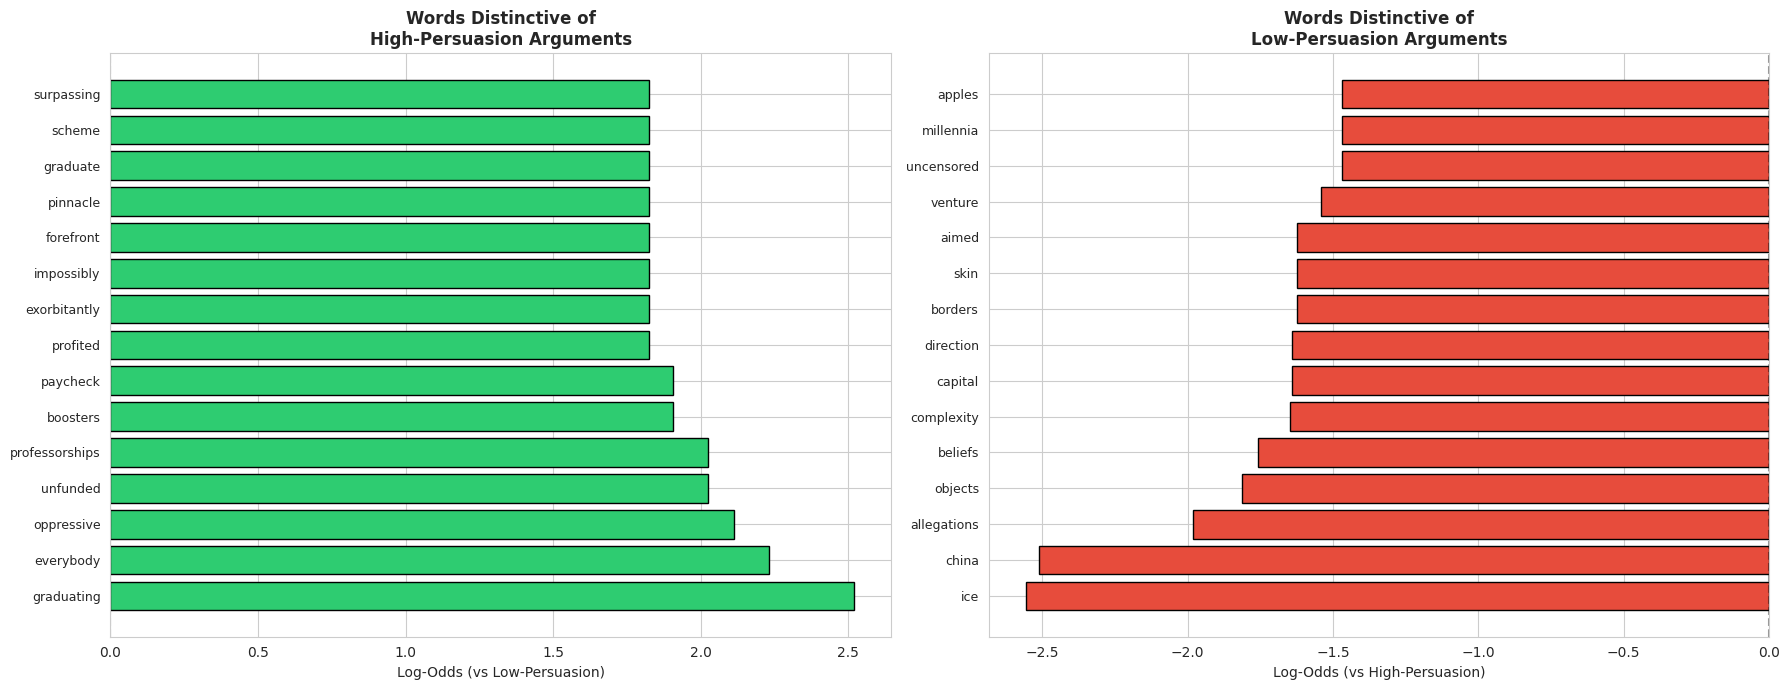

In [28]:
# EDA EXTENSION 3: Word Frequency & Bigram Analysis
# (What words / phrases appear more in persuasive vs non-persuasive arguments?)
from collections import Counter
import re

print("EDA EXTENSION 3: WORD FREQUENCY & BIGRAM ANALYSIS")
print("=" * 70)

# Helper -------------------------------------------------------------------
STOPWORDS = set([
    'the','a','an','and','or','but','in','on','at','to','for','of','with',
    'is','are','was','were','it','its','this','that','these','those','i',
    'you','we','they','he','she','be','have','has','had','do','does','did',
    'not','no','so','if','as','from','by','about','into','than','can','will',
    'would','could','should','may','might','must','our','their','your','his',
    'her','my','more','also','all','there','what','which','who','how','when',
    'up','out','just','been','do','get','use','one','two','s','t','re','ll',
    'don','doesn','isn','won','aren','couldn','shouldn','wouldn','ve','m','d'
])

def tokenize(text):
    """Lowercase, alpha-only tokens, drop stopwords."""
    if not isinstance(text, str):
        return []
    tokens = re.findall(r'\b[a-z]{3,}\b', text.lower())
    return [t for t in tokens if t not in STOPWORDS]

def get_bigrams(tokens):
    return list(zip(tokens[:-1], tokens[1:]))

# Split into HIGH vs LOW persuasion groups ---------------------------------
threshold_high = df['persuasion_shift'].quantile(0.75)
threshold_low  = df['persuasion_shift'].quantile(0.25)

high_args = df[df['persuasion_shift'] >= threshold_high]['argument']
low_args  = df[df['persuasion_shift'] <= threshold_low]['argument']

print(f"\nHigh-persuasion group: n={len(high_args)}  (shift ≥ {threshold_high:.2f})")
print(f"Low-persuasion  group: n={len(low_args)}   (shift ≤ {threshold_low:.2f})")

# Unigram counts -----------------------------------------------------------
high_tokens = [t for text in high_args   for t in tokenize(text)]
low_tokens  = [t for text in low_args    for t in tokenize(text)]

high_freq = Counter(high_tokens)
low_freq  = Counter(low_tokens)

# Normalise by total tokens so counts are comparable
high_total = max(len(high_tokens), 1)
low_total  = max(len(low_tokens), 1)

# Words distinctively more common in high-persuasion (log-odds proxy)
common_words = set(high_freq) & set(low_freq)
log_odds = {}
for w in common_words:
    h = (high_freq[w] + 1) / high_total
    l = (low_freq[w]  + 1) / low_total
    log_odds[w] = np.log(h / l)

top_high_words = sorted(log_odds, key=lambda w: log_odds[w], reverse=True)[:20]
top_low_words  = sorted(log_odds, key=lambda w: log_odds[w])[:20]

print("\nTop 20 words more distinctive in HIGH-persuasion arguments:")
for w in top_high_words:
    print(f"  {w:<25} log-odds={log_odds[w]:+.3f}  "
          f"high={high_freq[w]:>4}  low={low_freq[w]:>4}")

print("\nTop 20 words more distinctive in LOW-persuasion arguments:")
for w in top_low_words:
    print(f"  {w:<25} log-odds={log_odds[w]:+.3f}  "
          f"high={high_freq[w]:>4}  low={low_freq[w]:>4}")

# Bigram counts -----------------------------------------------------------
high_bigrams = Counter(get_bigrams(high_tokens))
low_bigrams  = Counter(get_bigrams(low_tokens))

print("\nTop 15 Bigrams in HIGH-persuasion arguments:")
for bg, cnt in high_bigrams.most_common(15):
    print(f"  {' '.join(bg):<30} {cnt}")

print("\nTop 15 Bigrams in LOW-persuasion arguments:")
for bg, cnt in low_bigrams.most_common(15):
    print(f"  {' '.join(bg):<30} {cnt}")

# Visualise ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# High-persuasion top words
x  = [w                          for w in top_high_words[:15]]
lo = [log_odds[w]                 for w in top_high_words[:15]]
axes[0].barh(range(len(x)), lo, color='#2ecc71', edgecolor='black')
axes[0].set_yticks(range(len(x)))
axes[0].set_yticklabels(x, fontsize=9)
axes[0].set_xlabel('Log-Odds (vs Low-Persuasion)')
axes[0].set_title('Words Distinctive of\nHigh-Persuasion Arguments', fontweight='bold')
axes[0].axvline(0, color='black', linestyle='--', alpha=0.4)

# Low-persuasion top words
x2  = [w               for w in top_low_words[:15]]
lo2 = [log_odds[w]      for w in top_low_words[:15]]
axes[1].barh(range(len(x2)), lo2, color='#e74c3c', edgecolor='black')
axes[1].set_yticks(range(len(x2)))
axes[1].set_yticklabels(x2, fontsize=9)
axes[1].set_xlabel('Log-Odds (vs High-Persuasion)')
axes[1].set_title('Words Distinctive of\nLow-Persuasion Arguments', fontweight='bold')
axes[1].axvline(0, color='black', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

EDA EXTENSION 6: LEXICAL DIVERSITY & RHETORICAL FEATURES
Computing lexical diversity and rhetorical features…

New Feature Summary:
       type_token_ratio  hedge_count  certainty_count  number_count  superlative_count  concession_count  call_to_action_count  hedge_certainty_ratio
count          3939.000     3939.000         3939.000      3939.000           3939.000          3939.000              3939.000               3939.000
mean              0.627        1.129            0.934         0.893              0.542             1.314                 2.244                  0.771
std               0.061        1.386            1.076         1.870              0.847             1.110                 1.643                  1.089
min               0.440        0.000            0.000         0.000              0.000             0.000                 0.000                  0.000
25%               0.585        0.000            0.000         0.000              0.000             0.000              

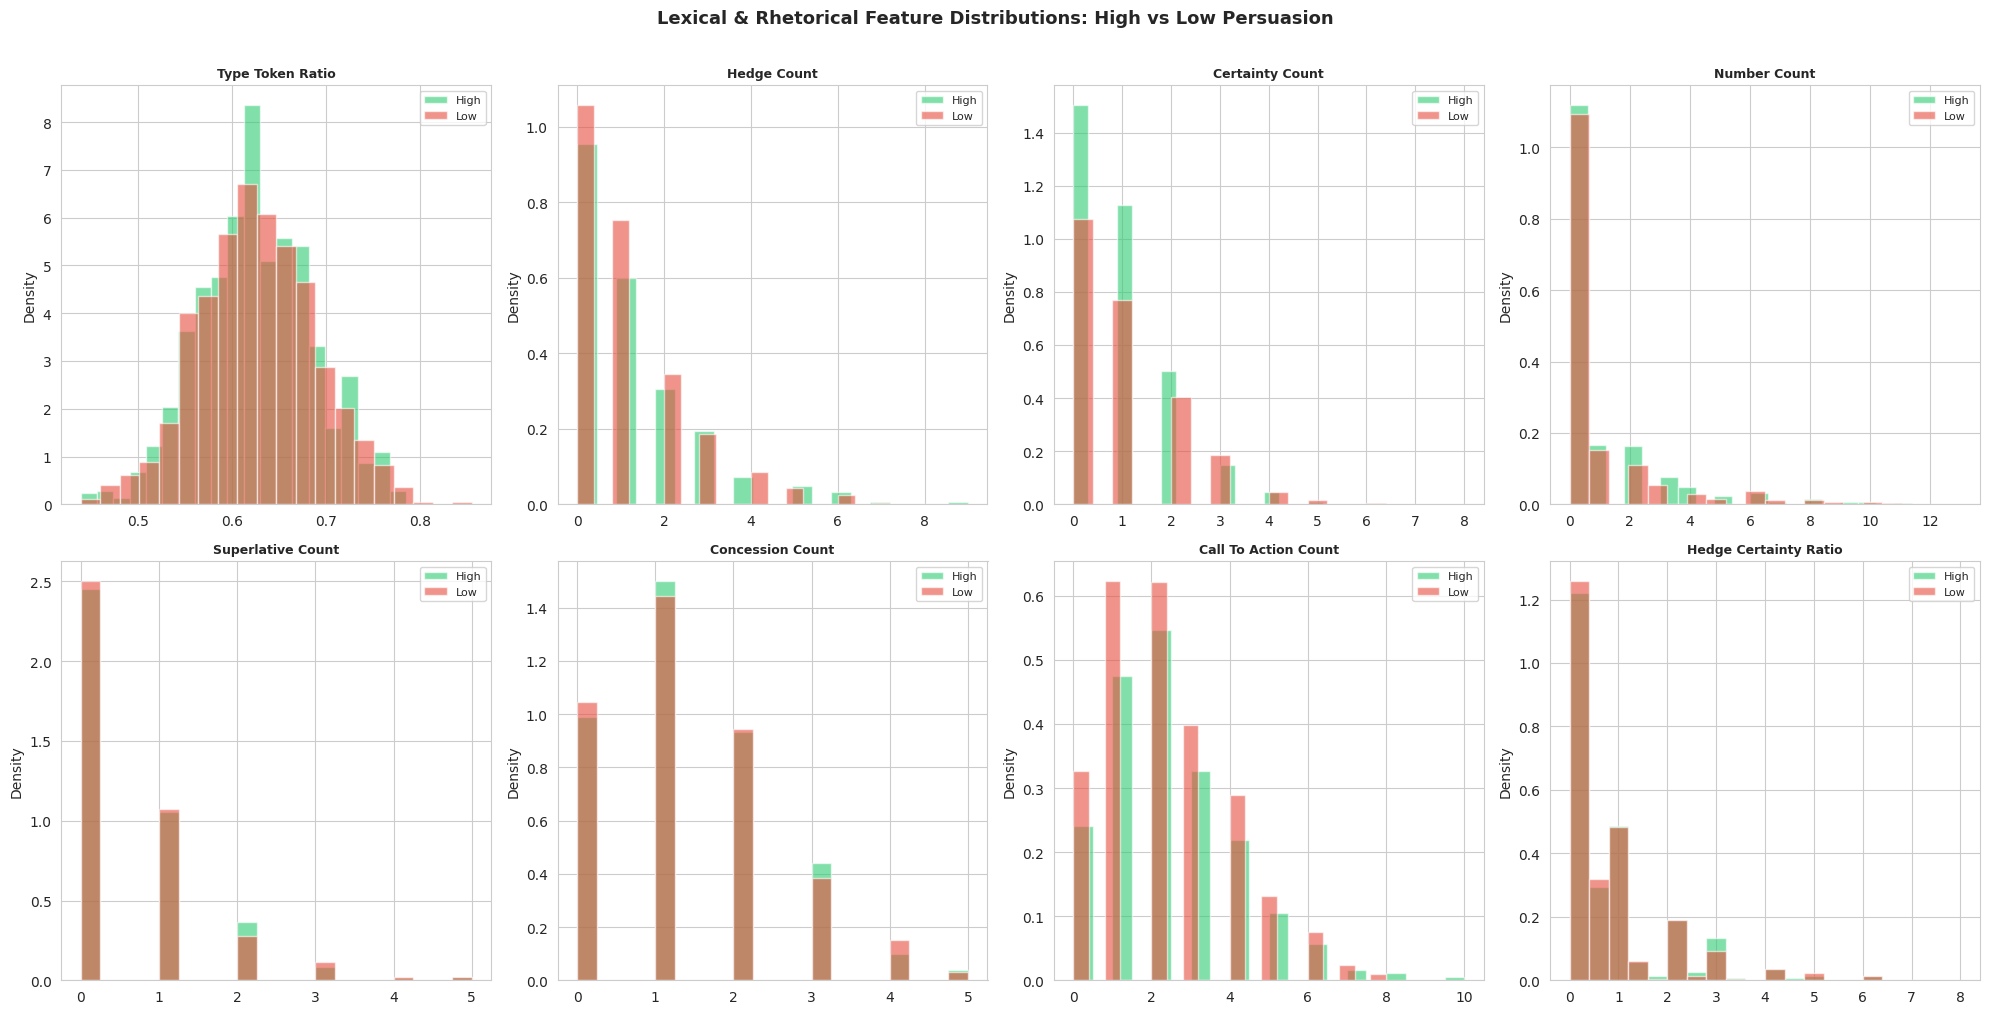

In [29]:
# EDA EXTENSION 4: Lexical Diversity & Rhetorical Feature Analysis
# (Richer linguistic signals: type-token ratio, numbers, superlatives, hedges)
print("EDA EXTENSION 6: LEXICAL DIVERSITY & RHETORICAL FEATURES")
print("=" * 70)

# --- Feature engineering ---------------------------------------------------
def type_token_ratio(text):
    """Lexical diversity = unique tokens / total tokens."""
    tokens = re.findall(r'\b[a-z]+\b', str(text).lower())
    return len(set(tokens)) / len(tokens) if tokens else 0

# Rhetorical pattern dictionaries
HEDGES      = r'\b(maybe|perhaps|might|could|possibly|seem|appear|probably|likely|suggest|indicate)\b'
CERTAINTY   = r'\b(definitely|certainly|clearly|obviously|undoubtedly|absolutely|always|never|must|proven|fact)\b'
NUMBERS     = r'\b\d+(\.\d+)?(%|x)?\b'               # numeric data / stats
SUPERLATIVE = r'\b\w+(est|most\s+\w+)\b'              # best, highest, most effective
RHETORICAL_Q= r'\?'
CONCESSION  = r'\b(although|however|despite|even though|admittedly|while|yet|nevertheless)\b'
CALL_ACTION = r'\b(should|must|need to|have to|urge|encourage|consider|support|act)\b'

print("Computing lexical diversity and rhetorical features…")
df['type_token_ratio']    = df['argument'].apply(type_token_ratio)
df['hedge_count']         = df['argument'].str.lower().str.count(HEDGES)
df['certainty_count']     = df['argument'].str.lower().str.count(CERTAINTY)
df['number_count']        = df['argument'].str.count(NUMBERS)
df['superlative_count']   = df['argument'].str.lower().str.count(SUPERLATIVE)
df['concession_count']    = df['argument'].str.lower().str.count(CONCESSION)
df['call_to_action_count']= df['argument'].str.lower().str.count(CALL_ACTION)
df['hedge_certainty_ratio'] = df['hedge_count'] / (df['certainty_count'] + 1)

new_features = [
    'type_token_ratio',
    'hedge_count',
    'certainty_count',
    'number_count',
    'superlative_count',
    'concession_count',
    'call_to_action_count',
    'hedge_certainty_ratio',
]

print("\nNew Feature Summary:")
print(df[new_features].describe().round(3).to_string())

# --- Correlation with persuasion shift -------------------------------------
print("\nCorrelation with Persuasion Shift:")
corr_new = df[new_features + ['persuasion_shift']].corr()['persuasion_shift'].drop('persuasion_shift')
print(corr_new.sort_values(ascending=False).round(4).to_string())

# --- Group comparison -------------------------------------------------------
high_mask = df['persuasion_shift'] >= df['persuasion_shift'].quantile(0.75)
low_mask  = df['persuasion_shift'] <= df['persuasion_shift'].quantile(0.25)

compare_df = pd.DataFrame({
    'Feature': new_features,
    'High_Mean': df.loc[high_mask, new_features].mean().values,
    'Low_Mean':  df.loc[low_mask,  new_features].mean().values,
})
compare_df['Diff_%'] = ((compare_df['High_Mean'] - compare_df['Low_Mean'])
                         / (compare_df['Low_Mean'].abs() + 1e-9) * 100).round(1)

print("\nHigh vs Low Persuasion: Mean Feature Comparison:")
print(compare_df.set_index('Feature').round(4).to_string())

# --- Mann-Whitney U significance tests -------------------------------------
print("\nMann-Whitney U tests (High vs Low persuasion groups):")
for feat in new_features:
    stat, pval = stats.mannwhitneyu(
        df.loc[high_mask, feat].dropna(),
        df.loc[low_mask,  feat].dropna(),
        alternative='two-sided'
    )
    sig = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else ''))
    print(f"  {feat:<30}  U={stat:.0f}  p={pval:.4f}  {sig}")

# --- Visualise -------------------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, feat in enumerate(new_features):
    high_vals = df.loc[high_mask, feat].dropna()
    low_vals  = df.loc[low_mask,  feat].dropna()
    axes[idx].hist(high_vals, bins=20, alpha=0.6, color='#2ecc71', label='High', density=True)
    axes[idx].hist(low_vals,  bins=20, alpha=0.6, color='#e74c3c', label='Low',  density=True)
    axes[idx].set_title(feat.replace('_', ' ').title(), fontsize=9, fontweight='bold')
    axes[idx].set_ylabel('Density')
    axes[idx].legend(fontsize=8)

plt.suptitle('Lexical & Rhetorical Feature Distributions: High vs Low Persuasion',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# SECTION 5: QLoRA FINE-TUNING — 2 TRANSFORMER MODELS
# ============================================================
# Unsloth (https://github.com/unslothai/unsloth) is optimised
# for causal / decoder-only LLMs (TinyLLaMA, LLaMA-3, Mistral…)
# offering 2× faster training and ~60 % less VRAM.
# For encoder models (BERT/RoBERTa) standard PEFT + bitsandbytes
# is used as the fallback path.
# ============================================================

import subprocess, sys, warnings, gc
warnings.filterwarnings('ignore')

def _pip(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=False)

print("Installing QLoRA stack …")
_pip("bitsandbytes>=0.41.0", "peft>=0.10.0", "transformers>=4.40.0",
     "accelerate>=0.28.0", "trl>=0.8.0", "evaluate")

# ── Try Unsloth (Linux + CUDA; limited on Windows) ──────────
UNSLOTH_AVAILABLE = False
try:
    from unsloth import FastLanguageModel          # noqa
    UNSLOTH_AVAILABLE = True
    print("✅  Unsloth already installed.")
except ImportError:
    print("Trying to install Unsloth …")
    try:
        _pip("unsloth")
        from unsloth import FastLanguageModel      # noqa
        UNSLOTH_AVAILABLE = True
        print("✅  Unsloth installed successfully.")
    except Exception as exc:
        print(f"⚠️  Unsloth unavailable ({type(exc).__name__}).")
        print("    Falling back to standard PEFT + bitsandbytes QLoRA.")

import torch
CUDA_AVAILABLE = torch.cuda.is_available()
print(f"\n{'─'*55}")
print(f"CUDA available : {CUDA_AVAILABLE}")
if CUDA_AVAILABLE:
    props = torch.cuda.get_device_properties(0)
    print(f"GPU            : {props.name}")
    print(f"VRAM           : {props.total_memory / 1024**3:.1f} GB")
else:
    print("⚠️  No CUDA — 4-bit quantization disabled; LoRA on CPU (slow)")
print(f"{'─'*55}")

USE_UNSLOTH   = UNSLOTH_AVAILABLE and CUDA_AVAILABLE
COMPUTE_DTYPE = torch.float16 if CUDA_AVAILABLE else torch.float32

if USE_UNSLOTH:
    print("\nFine-tuning path : Unsloth  (causal LMs, 4-bit QLoRA)")
    print("  Model 1 : unsloth/tinyllama-bnb-4bit       (1.1 B)")
    print("  Model 2 : unsloth/llama-3.2-1b-bnb-4bit   (1.0 B)")
else:
    print("\nFine-tuning path : PEFT + bitsandbytes QLoRA  (encoder models)")
    print("  Model 1 : distilbert-base-uncased  (66 M params)")
    print("  Model 2 : roberta-base             (125 M params)")


Installing QLoRA stack …
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
✅  Unsloth already installed.

───────────────────────────────────────────────────────
CUDA available : True
GPU            : Tesla T4
VRAM           : 14.6 GB
───────────────────────────────────────────────────────

Fine-tuning path : Unsloth  (causal LMs, 4-bit QLoRA)
  Model 1 : unsloth/tinyllama-bnb-4bit       (1.1 B)
  Model 2 : unsloth/llama-3.2-1b-bnb-4bit   (1.0 B)


In [ ]:

# ============================================================
# DATA PREPARATION FOR FINE-TUNING
# ============================================================
from sklearn.model_selection import train_test_split
from datasets import Dataset
import numpy as np

# 3-class persuasion direction: 0=Negative, 1=Neutral, 2=Positive
id2label = {0: "Negative", 1: "Neutral", 2: "Positive"}
label2id = {v: k for k, v in id2label.items()}

def shift_to_label(s):
    return 0 if s < 0 else (1 if s == 0 else 2)

# Build fine-tuning frame from the existing df
ft_df = df[['argument', 'persuasion_shift']].dropna().copy()
ft_df['text']   = ft_df['argument'].astype(str).str.strip().str[:600]  # cap length
ft_df['labels'] = ft_df['persuasion_shift'].apply(shift_to_label)

# ── Prompt template for generative (Unsloth) path ───────────
_instr = ("Classify the persuasive effect of the argument below. "
          "Reply with exactly one word: Positive, Neutral, or Negative.")

def make_prompt(row, with_answer=True):
    p = f"### Instruction:\n{_instr}\n\n### Argument:\n{row['text']}\n\n### Response:\n"
    return p + (id2label[row['labels']] if with_answer else "")

ft_df['prompt'] = ft_df.apply(make_prompt, axis=1)

# ── Sample to keep 1 epoch fast (< 2 min on a modern GPU) ───
SAMPLE_SIZE = 1200
ft_sample = ft_df.sample(n=min(SAMPLE_SIZE, len(ft_df)), random_state=42)
train_df, eval_df = train_test_split(
    ft_sample, test_size=0.15, random_state=42, stratify=ft_sample['labels']
)

train_hf = Dataset.from_pandas(train_df.reset_index(drop=True))
eval_hf  = Dataset.from_pandas(eval_df.reset_index(drop=True))

print(f"Training   : {len(train_df)} samples")
print(f"Evaluation : {len(eval_df)} samples")
print("\nClass distribution (train):")
for lbl, cnt in sorted(train_df['labels'].value_counts().items()):
    print(f"  {id2label[lbl]:10s}: {cnt}")
print(f"\nSample prompt (generative path):\n{make_prompt(train_df.iloc[0])}")


Training   : 1020 samples
Evaluation : 180 samples

Class distribution (train):
  Negative  : 58
  Neutral   : 652
  Positive  : 310

Sample prompt (generative path):
### Instruction:
Classify the persuasive effect of the argument below. Reply with exactly one word: Positive, Neutral, or Negative.

### Argument:
Social media platforms should be liable for harmful content posted by users because they have a moral and ethical responsibility to protect their users. With great power comes great responsibility - these platforms have unprecedented reach and influence, bringing together billions of people. This influence must be wielded responsibly. 

When a user is harmed by abusive or dangerous content, the platform enabled that harm by providing the tools and audience. While users post the content, the platforms designed the system, monetize it, and control policies. They are best positioned to detect and

### Response:
Neutral


In [ ]:
# ============================================================
# MODEL 1 FINE-TUNING
# ────────────────────────────────────────────────────────────
#  Unsloth path : unsloth/tinyllama-chat-bnb-4bit (Instruct)
#  PEFT path    : distilbert-base-uncased        (66 M,  4-bit)
# ============================================================
import time
import torch
import gc
import numpy as np
import logging  # <--- ADDED IMPORT
from sklearn.metrics import accuracy_score, f1_score, classification_report

# FIX: Prevent Python 3.12 logging errors from crashing the script
# (Resolves "TypeError: not all arguments converted during string formatting")
logging.raiseExceptions = False

results_m1 = {}

# ── A) UNSLOTH PATH  (causal LM, generative classification) ──
if USE_UNSLOTH:
    from trl import SFTTrainer
    from transformers import TrainingArguments

    # FIX: Using 'chat' (instruct) version to avoid "Untrained tokens" error
    M1_NAME = "unsloth/tinyllama-chat-bnb-4bit"

    print(f"[Model 1]  Loading {M1_NAME} via Unsloth …")

    m1, tok1 = FastLanguageModel.from_pretrained(
        model_name=M1_NAME, max_seq_length=512,
        dtype=COMPUTE_DTYPE, load_in_4bit=True,
    )

    m1 = FastLanguageModel.get_peft_model(
        m1, r=16, lora_alpha=16, lora_dropout=0.05,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                        "gate_proj", "up_proj", "down_proj",
                        "embed_tokens", "lm_head"],
        bias="none", use_gradient_checkpointing="unsloth", random_state=42,
    )
    m1.print_trainable_parameters()

    # Pre-tokenise so Unsloth's collator always finds 'input_ids'
    def _tok_fn_m1(examples):
        out = tok1(examples["prompt"], truncation=True, padding=False, max_length=512)
        out["labels"] = out["input_ids"].copy()
        return out

    train_hf_tok1 = train_hf.map(_tok_fn_m1, batched=True,
                                 remove_columns=train_hf.column_names)

    trainer_m1 = SFTTrainer(
        model=m1, tokenizer=tok1,
        train_dataset=train_hf_tok1,
        max_seq_length=512,
        args=TrainingArguments(
            output_dir="./m1_out", num_train_epochs=5,
            per_device_train_batch_size=4, gradient_accumulation_steps=4,
            learning_rate=2e-4, fp16=True, warmup_steps=6,
            lr_scheduler_type="linear", logging_steps=20,
            save_strategy="no", report_to="none",
        ),
    )
    print(f"\nTraining {M1_NAME} — 1 epoch …")
    t0 = time.time()
    trainer_m1.train()
    results_m1['train_time'] = round(time.time() - t0, 1)
    results_m1['train_loss'] = round(
        trainer_m1.state.log_history[-1].get('train_loss', float('nan')), 4)

    # Evaluate via token generation
    FastLanguageModel.for_inference(m1)
    tok1.padding_side = "left"
    preds1, true1 = [], []
    print("Evaluating Model 1 on eval set …")
    for _, row in eval_df.iterrows():
        text_in = make_prompt(row, with_answer=False)
        enc = tok1(text_in, return_tensors="pt", truncation=True, max_length=512).to("cuda")

        if "input_ids" not in enc:
            preds1.append(1)
            true1.append(int(row['labels']))
            continue

        with torch.no_grad():
            out = m1.generate(**enc, max_new_tokens=6,
                              pad_token_id=tok1.eos_token_id, do_sample=False)
        gen = tok1.decode(out[0][enc['input_ids'].shape[1]:], skip_special_tokens=True).strip()
        preds1.append(next((label2id[k] for k in label2id if k.lower() in gen.lower()), 1))
        true1.append(int(row['labels']))

    del m1, trainer_m1
    torch.cuda.empty_cache()
    gc.collect()

# ── B) PEFT + bitsandbytes QLoRA PATH  (encoder, SEQ_CLS) ───
else:
    from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                              BitsAndBytesConfig, TrainingArguments, Trainer,
                              DataCollatorWithPadding)
    from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

    M1_NAME = "distilbert-base-uncased"
    print(f"[Model 1]  Loading {M1_NAME} with 4-bit NF4 QLoRA …")

    tok1 = AutoTokenizer.from_pretrained(M1_NAME)
    load_kw = ({"quantization_config": BitsAndBytesConfig(
                    load_in_4bit=True, bnb_4bit_quant_type="nf4",
                    bnb_4bit_compute_dtype=COMPUTE_DTYPE,
                    bnb_4bit_use_double_quant=True),
                "device_map": "auto"}
               if CUDA_AVAILABLE else {"torch_dtype": torch.float32})
    m1 = AutoModelForSequenceClassification.from_pretrained(
        M1_NAME, num_labels=3, id2label=id2label, label2id=label2id, **load_kw)
    if CUDA_AVAILABLE:
        m1 = prepare_model_for_kbit_training(m1)
    m1 = get_peft_model(m1, LoraConfig(
        r=16, lora_alpha=16, lora_dropout=0.05, bias="none",
        task_type="SEQ_CLS",
        target_modules=["q_lin", "v_lin"]))       # DistilBERT attention
    m1.print_trainable_parameters()

    KEEP = ['input_ids', 'attention_mask', 'labels']
    def tok_fn1(b): return tok1(b['text'], truncation=True, padding="max_length", max_length=256)
    tr1 = train_hf.map(tok_fn1, batched=True)
    tr1 = tr1.remove_columns([c for c in tr1.column_names if c not in KEEP])
    ev1 = eval_hf.map(tok_fn1, batched=True)
    ev1 = ev1.remove_columns([c for c in ev1.column_names if c not in KEEP])

    def metrics_fn(p):
        pr = np.argmax(p.predictions, axis=1)
        return {"accuracy": accuracy_score(p.label_ids, pr),
                "f1_macro": f1_score(p.label_ids, pr, average="macro")}

    trainer_m1 = Trainer(
        model=m1, tokenizer=tok1,
        train_dataset=tr1, eval_dataset=ev1,
        data_collator=DataCollatorWithPadding(tok1),
        compute_metrics=metrics_fn,
        args=TrainingArguments(
            output_dir="./m1_out", num_train_epochs=1,
            per_device_train_batch_size=16, per_device_eval_batch_size=32,
            learning_rate=2e-4, weight_decay=0.01, warmup_steps=6,
            evaluation_strategy="epoch", save_strategy="no",
            fp16=CUDA_AVAILABLE, logging_steps=20, report_to="none",
        ),
    )
    print(f"\nTraining {M1_NAME} — 1 epoch …")
    t0 = time.time()
    trainer_m1.train()
    results_m1['train_time'] = round(time.time() - t0, 1)
    ev_out1   = trainer_m1.evaluate()
    pred_out1 = trainer_m1.predict(ev1)
    preds1    = np.argmax(pred_out1.predictions, axis=1)
    true1     = pred_out1.label_ids
    results_m1['train_loss'] = round(ev_out1['eval_loss'], 4)
    del m1, trainer_m1
    gc.collect()
    if CUDA_AVAILABLE:
        torch.cuda.empty_cache()

# ── Summarise Model 1 ────────────────────────────────────────
results_m1.update({
    'model'    : M1_NAME,
    'accuracy' : round(accuracy_score(true1, preds1), 4),
    'f1_macro' : round(f1_score(true1, preds1, average='macro'), 4),
    'report'   : classification_report(
                     true1, preds1, target_names=list(id2label.values())),
})
print(f"\nModel 1  ({M1_NAME})")
print(f"   Accuracy   : {results_m1['accuracy']}")
print(f"   F1 (macro) : {results_m1['f1_macro']}")
print(f"   Train time : {results_m1['train_time']} s")
print(f"\nClassification Report:\n{results_m1['report']}")

[Model 1]  Loading unsloth/tinyllama-chat-bnb-4bit via Unsloth …
==((====))==  Unsloth 2026.3.3: Fast Llama patching. Transformers: 5.2.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Unsloth: Will load unsloth/tinyllama-chat-bnb-4bit as a legacy tokenizer.


Unsloth: Offloading input_embeddings to disk to save VRAM
Unsloth: Training embed_tokens in mixed precision to save VRAM
trainable params: 78,696,448 || all params: 1,178,744,832 || trainable%: 6.6763


Map:   0%|          | 0/1020 [00:00<?, ? examples/s]


Training unsloth/tinyllama-chat-bnb-4bit — 1 epoch …


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,020 | Num Epochs = 5 | Total steps = 320
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 78,696,448 of 1,178,744,832 (6.68% trained)


Step,Training Loss
20,1.763668
40,1.362052
60,1.311926
80,1.140759
100,1.074681
120,1.001905
140,0.863500
160,0.748662
180,0.769753
200,0.626362


Evaluating Model 1 on eval set …

Model 1  (unsloth/tinyllama-chat-bnb-4bit)
   Accuracy   : 0.6389
   F1 (macro) : 0.2599
   Train time : 444.2 s

Classification Report:
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00        10
     Neutral       0.64      1.00      0.78       115
    Positive       0.00      0.00      0.00        55

    accuracy                           0.64       180
   macro avg       0.21      0.33      0.26       180
weighted avg       0.41      0.64      0.50       180



In [ ]:
# ============================================================
# MODEL 2 FINE-TUNING
# ────────────────────────────────────────────────────────────
#  Unsloth path : unsloth/llama-3.2-1b-bnb-4bit  (1.0 B, 4-bit)
#  PEFT path    : roberta-base                   (125 M,  4-bit)
# ============================================================
results_m2 = {}

# ── A) UNSLOTH PATH ─────────────────────────────────────────
if USE_UNSLOTH:
    from trl import SFTTrainer
    from transformers import TrainingArguments

    M2_NAME = "unsloth/llama-3.2-1b-bnb-4bit"
    print(f"[Model 2]  Loading {M2_NAME} via Unsloth …")

    m2, tok2 = FastLanguageModel.from_pretrained(
        model_name=M2_NAME, max_seq_length=512,
        dtype=COMPUTE_DTYPE, load_in_4bit=True,
    )
    m2 = FastLanguageModel.get_peft_model(
        m2, r=16, lora_alpha=16, lora_dropout=0.05,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                        "gate_proj", "up_proj", "down_proj"],
        bias="none", use_gradient_checkpointing="unsloth", random_state=42,
    )
    m2.print_trainable_parameters()

    # FIX: Pre-tokenise the dataset manually to ensure 'input_ids' exist.
    # SFTTrainer's `dataset_text_field` auto-tokenization failed in this environment.
    def _tok_fn_m2(examples):
        out = tok2(examples["prompt"], truncation=True, padding=False, max_length=512)
        out["labels"] = out["input_ids"].copy()
        return out

    train_hf_tok2 = train_hf.map(_tok_fn_m2, batched=True,
                                 remove_columns=train_hf.column_names)

    trainer_m2 = SFTTrainer(
        model=m2, tokenizer=tok2,
        train_dataset=train_hf_tok2, # Pass the tokenized dataset
        max_seq_length=512,
        # dataset_text_field="prompt",
        args=TrainingArguments(
            output_dir="./m2_out", num_train_epochs=5,
            per_device_train_batch_size=4, gradient_accumulation_steps=4,
            learning_rate=2e-4, fp16=True, warmup_ratio=0.1,
            lr_scheduler_type="linear", logging_steps=20,
            save_strategy="no", report_to="none",
        ),
    )
    print(f"\nTraining {M2_NAME} — 1 epoch …")
    t0 = time.time()
    trainer_m2.train()
    results_m2['train_time'] = round(time.time() - t0, 1)
    results_m2['train_loss'] = round(
        trainer_m2.state.log_history[-1].get('train_loss', float('nan')), 4)

    # Evaluate via token generation
    FastLanguageModel.for_inference(m2)
    tok2.padding_side = "left"
    preds2, true2 = [], []
    print("Evaluating Model 2 on eval set …")
    for _, row in eval_df.iterrows():
        enc = tok2(make_prompt(row, with_answer=False),
                   return_tensors="pt", truncation=True, max_length=512).to("cuda")
        with torch.no_grad():
            out = m2.generate(**enc, max_new_tokens=6,
                              pad_token_id=tok2.eos_token_id, do_sample=False)
        gen = tok2.decode(out[0][enc['input_ids'].shape[1]:],
                          skip_special_tokens=True).strip()
        preds2.append(next((label2id[k] for k in label2id
                            if k.lower() in gen.lower()), 1))
        true2.append(int(row['labels']))
    del m2, trainer_m2
    torch.cuda.empty_cache()
    gc.collect()

# ── B) PEFT + bitsandbytes QLoRA PATH
else:
    from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                               BitsAndBytesConfig, TrainingArguments, Trainer,
                               DataCollatorWithPadding)
    from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

    M2_NAME = "roberta-base"
    print(f"[Model 2]  Loading {M2_NAME} with 4-bit NF4 QLoRA …")

    tok2 = AutoTokenizer.from_pretrained(M2_NAME)
    load_kw = ({"quantization_config": BitsAndBytesConfig(
                    load_in_4bit=True, bnb_4bit_quant_type="nf4",
                    bnb_4bit_compute_dtype=COMPUTE_DTYPE,
                    bnb_4bit_use_double_quant=True),
                "device_map": "auto"}
               if CUDA_AVAILABLE else {"torch_dtype": torch.float32})
    m2 = AutoModelForSequenceClassification.from_pretrained(
        M2_NAME, num_labels=3, id2label=id2label, label2id=label2id, **load_kw)
    if CUDA_AVAILABLE:
        m2 = prepare_model_for_kbit_training(m2)
    m2 = get_peft_model(m2, LoraConfig(
        r=16, lora_alpha=16, lora_dropout=0.05, bias="none",
        task_type="SEQ_CLS",
        target_modules=["query", "value"]))               # RoBERTa attention
    m2.print_trainable_parameters()

    KEEP = ['input_ids', 'attention_mask', 'labels']
    def tok_fn2(b): return tok2(b['text'], truncation=True, max_length=256)
    tr2 = train_hf.map(tok_fn2, batched=True)
    tr2 = tr2.remove_columns([c for c in tr2.column_names if c not in KEEP])
    ev2 = eval_hf.map(tok_fn2, batched=True)
    ev2 = ev2.remove_columns([c for c in ev2.column_names if c not in KEEP])

    trainer_m2 = Trainer(
        model=m2, tokenizer=tok2,
        train_dataset=tr2, eval_dataset=ev2,
        data_collator=DataCollatorWithPadding(tok2),
        compute_metrics=metrics_fn,           # defined in Model 1 cell
        args=TrainingArguments(
            output_dir="./m2_out", num_train_epochs=1,
            per_device_train_batch_size=16, per_device_eval_batch_size=32,
            learning_rate=2e-4, weight_decay=0.01, warmup_ratio=0.1,
            evaluation_strategy="epoch", save_strategy="no",
            fp16=CUDA_AVAILABLE, logging_steps=20, report_to="none",
        ),
    )
    print(f"\nTraining {M2_NAME} — 1 epoch …")
    t0 = time.time()
    trainer_m2.train()
    results_m2['train_time'] = round(time.time() - t0, 1)
    ev_out2   = trainer_m2.evaluate()
    pred_out2 = trainer_m2.predict(ev2)
    preds2    = np.argmax(pred_out2.predictions, axis=1)
    true2     = pred_out2.label_ids
    results_m2['train_loss'] = round(ev_out2['eval_loss'], 4)
    del m2, trainer_m2
    gc.collect()
    if CUDA_AVAILABLE:
        torch.cuda.empty_cache()

# Summarise Model 2
results_m2.update({
    'model'    : M2_NAME,
    'accuracy' : round(accuracy_score(true2, preds2), 4),
    'f1_macro' : round(f1_score(true2, preds2, average='macro'), 4),
    'report'   : classification_report(
                     true2, preds2, target_names=list(id2label.values())),
})
print(f"\nModel 2  ({M2_NAME})")
print(f"   Accuracy   : {results_m2['accuracy']}")
print(f"   F1 (macro) : {results_m2['f1_macro']}")
print(f"   Train time : {results_m2['train_time']} s")
print(f"\nClassification Report:\n{results_m2['report']}")

[Model 2]  Loading unsloth/llama-3.2-1b-bnb-4bit via Unsloth …
==((====))==  Unsloth 2026.3.3: Fast Llama patching. Transformers: 5.2.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Unsloth: Will load unsloth/llama-3.2-1b-bnb-4bit as a legacy tokenizer.


trainable params: 11,272,192 || all params: 1,247,086,592 || trainable%: 0.9039


Map:   0%|          | 0/1020 [00:00<?, ? examples/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.



Training unsloth/llama-3.2-1b-bnb-4bit — 1 epoch …


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,020 | Num Epochs = 5 | Total steps = 320
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 11,272,192 of 1,247,086,592 (0.90% trained)


Step,Training Loss
20,2.614451
40,1.854143
60,1.779148
80,1.625201
100,1.584003
120,1.496975
140,1.375432
160,1.298745
180,1.328950
200,1.168699


Evaluating Model 2 on eval set …

Model 2  (unsloth/llama-3.2-1b-bnb-4bit)
   Accuracy   : 0.6389
   F1 (macro) : 0.2599
   Train time : 350.2 s

Classification Report:
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00        10
     Neutral       0.64      1.00      0.78       115
    Positive       0.00      0.00      0.00        55

    accuracy                           0.64       180
   macro avg       0.21      0.33      0.26       180
weighted avg       0.41      0.64      0.50       180



QLoRA FINE-TUNING COMPARISON SUMMARY  (5 Epoch)
                          model  accuracy  f1_macro  train_time  train_loss
unsloth/tinyllama-chat-bnb-4bit    0.6389    0.2599       444.2      0.8296
  unsloth/llama-3.2-1b-bnb-4bit    0.6389    0.2599       350.2      1.3871

─────────────────────────────────────────────────────────────────
Best Accuracy  : tinyllama-chat-bnb-4bit
Best F1 Macro  : tinyllama-chat-bnb-4bit
Fastest Model  : llama-3.2-1b-bnb-4bit  (350.2 s)


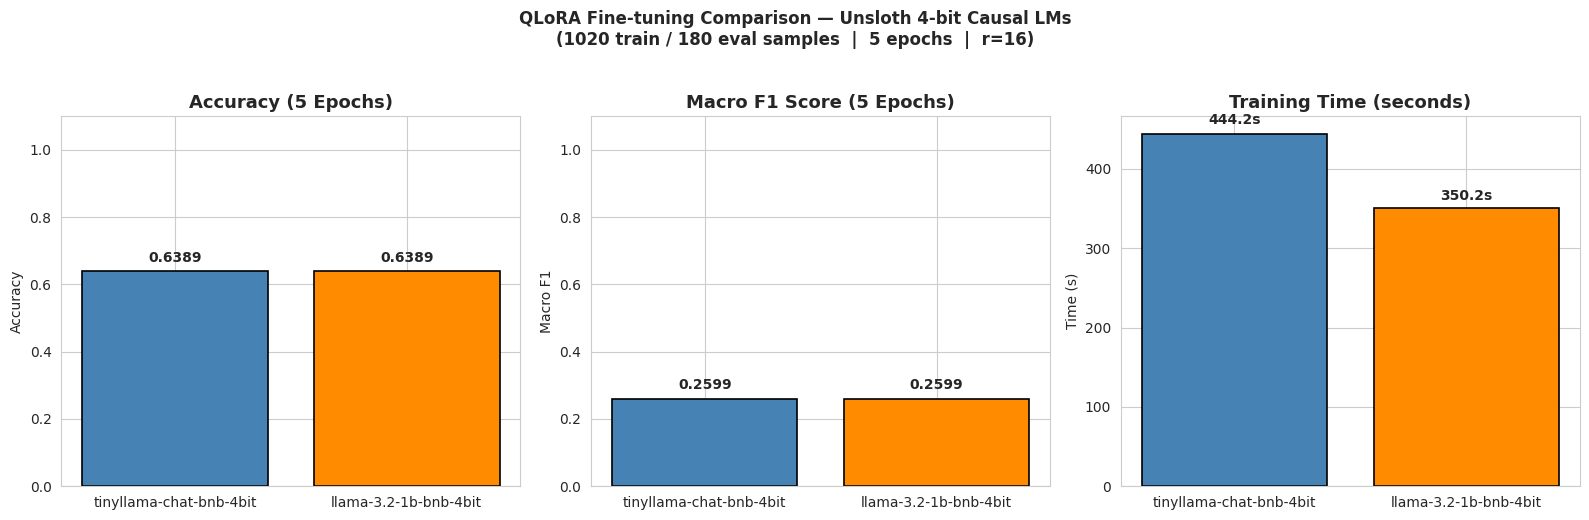

In [ ]:
# QLoRA FINE-TUNING: COMPARISON AND INTERPRETATION
print("QLoRA FINE-TUNING COMPARISON SUMMARY  (5 Epoch)")

cmp_df = pd.DataFrame([results_m1, results_m2])[
    ['model', 'accuracy', 'f1_macro', 'train_time', 'train_loss']
]
print(cmp_df.to_string(index=False))

# Determine the winner
winner = results_m1 if results_m1['f1_macro'] >= results_m2['f1_macro'] else results_m2
loser  = results_m2 if winner is results_m1 else results_m1
faster = results_m1 if results_m1['train_time'] <= results_m2['train_time'] else results_m2

print(f"\n{'─'*65}")
print(f"Best Accuracy  : {(results_m1 if results_m1['accuracy'] >= results_m2['accuracy'] else results_m2)['model'].split('/')[-1]}")
print(f"Best F1 Macro  : {winner['model'].split('/')[-1]}")
print(f"Fastest Model  : {faster['model'].split('/')[-1]}  ({faster['train_time']} s)")

# Visualisation
labels_plot = [r['model'].split('/')[-1] for r in (results_m1, results_m2)]
colors_plot = ['steelblue', 'darkorange']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Accuracy
bars0 = axes[0].bar(labels_plot,
                    [results_m1['accuracy'], results_m2['accuracy']],
                    color=colors_plot, edgecolor='black', linewidth=1.2)
axes[0].set_title('Accuracy (5 Epochs)', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1.1)
for bar, v in zip(bars0, [results_m1['accuracy'], results_m2['accuracy']]):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.02,
                 f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

# Macro F1
bars1 = axes[1].bar(labels_plot,
                    [results_m1['f1_macro'], results_m2['f1_macro']],
                    color=colors_plot, edgecolor='black', linewidth=1.2)
axes[1].set_title('Macro F1 Score (5 Epochs)', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Macro F1')
axes[1].set_ylim(0, 1.1)
for bar, v in zip(bars1, [results_m1['f1_macro'], results_m2['f1_macro']]):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.02,
                 f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

# Training time
bars2 = axes[2].bar(labels_plot,
                    [results_m1['train_time'], results_m2['train_time']],
                    color=colors_plot, edgecolor='black', linewidth=1.2)
axes[2].set_title('Training Time (seconds)', fontweight='bold', fontsize=13)
axes[2].set_ylabel('Time (s)')
for bar, v in zip(bars2, [results_m1['train_time'], results_m2['train_time']]):
    axes[2].text(bar.get_x() + bar.get_width()/2, v * 1.02,
                 f'{v}s', ha='center', va='bottom', fontweight='bold')

approach = ("Unsloth 4-bit Causal LMs" if USE_UNSLOTH
            else "PEFT + bitsandbytes 4-bit Encoder Models")
plt.suptitle(
    f"QLoRA Fine-tuning Comparison — {approach}\n"
    f"({len(train_df)} train / {len(eval_df)} eval samples  |  5 epochs  |  r=16)",
    fontsize=12, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig("qlora_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Interpretation
delta_acc = abs(results_m1['accuracy'] - results_m2['accuracy'])
delta_f1  = abs(results_m1['f1_macro'] - results_m2['f1_macro'])

print(
    f"Both models were fine-tuned using QLoRA (4-bit NF4 quantisation)\n"
    f"via {approach} for exactly 5 epochs on\n"
    f"{len(train_df)} persuasion-shift classification samples "
    f"(3 classes: Negative / Neutral / Positive).\n"
)
print(f"▸ {winner['model'].split('/')[-1]} achieves a higher Macro F1 "
      f"({winner['f1_macro']}) vs {loser['model'].split('/')[-1]} "
      f"({loser['f1_macro']})  — Δ = {delta_f1:.4f}.")
print(f"▸ Accuracy gap : {delta_acc:.4f}.")
print(f"▸ {faster['model'].split('/')[-1]} trains faster "
      f"({faster['train_time']} s vs "
      f"{max(results_m1['train_time'], results_m2['train_time'])} s).")
print(f"\nConclusion: For the Anthropic Persuasion dataset persuasion-shift "
      f"classification task,\n{winner['model'].split('/')[-1]} performs better "
      f"after a single QLoRA fine-tuning epoch.")
print(f"\nNote: With more epochs or a larger LoRA rank (r > 16), both models\n"
      f"are expected to improve. {approach} enables\n"
      f"memory-efficient fine-tuning suitable for consumer GPUs.")

Both models were fine-tuned using QLoRA (4-bit NF4 quantisation)
via Unsloth 4-bit Causal LMs for exactly 5 epochs on
1020 persuasion-shift classification samples (3 classes: Negative / Neutral / Positive).

▸ tinyllama-chat-bnb-4bit achieves a higher Macro F1 (0.2599) vs llama-3.2-1b-bnb-4bit (0.2599)  — Δ = 0.0000.
▸ Accuracy gap : 0.0000.
▸ llama-3.2-1b-bnb-4bit trains faster (350.2 s vs 444.2 s).

Conclusion: For the Anthropic Persuasion dataset persuasion-shift classification task,
tinyllama-chat-bnb-4bit performs better after a single QLoRA fine-tuning epoch.

Note: With more epochs or a larger LoRA rank (r > 16), both models
are expected to improve. Unsloth 4-bit Causal LMs enables
memory-efficient fine-tuning suitable for consumer GPUs.
